# COMP5329 Assignment 2: SAM and Out-of-Distribution Generalization

This notebook is the executable companion for the project report **Why Does SAM Improve Out-of-Distribution Generalization? Beyond Flatness Toward Stable Representations**.

It is organized to match the assignment expectation of a research-oriented workflow rather than a simple script log:

```text
1. Research question and hypothesis
2. Reproducibility setup
3. Dataset and experimental design
4. Training and checkpoint generation
5. OOD robustness evaluation
6. Mechanism analysis: calibration, sharpness and representation stability
7. Layer-wise and correlation analysis
8. Visualisation and report assets
9. Reproducibility checklist
```

Project files used by this notebook:

```text
COMP5329ASS2/
├── config.py
├── data.py
├── download_cifar10c.py
├── main_train.py
├── main_eval_ood.py
├── main_analysis.py
├── main_layer_analysis.py
├── main_correlation.py
├── plots.py
├── checkpoints/
├── results/
└── figures/
```


## 0. Research Question and Assignment Alignment

The assignment asks for a clear research question, a sound method, fair experiments, and analysis that goes beyond reporting raw performance. This project therefore studies the following mechanism-focused question:

> Does Sharpness-Aware Minimization improve CIFAR-10-C out-of-distribution robustness mainly by finding flatter minima, or is its behavior better explained by representation stability under corruptions?

The central hypothesis is deliberately testable: if SAM's robustness is mainly explained by flatness, SAM models should show both better corruption accuracy and lower measured sharpness than the baselines. If representation stability is the stronger explanation, the best OOD model should also maintain the most stable penultimate-layer features between clean and corrupted inputs.

The notebook supports this question by generating the checkpoints, CSV result files, statistical summaries, and visualisations used in the report.


## 1. Reproducibility Setup

This section prepares the Colab/Google Drive environment. Run it before any experiment cell. The paths are written for the project folder `COMP5329ASS2` in Google Drive.


### 1.1 Mount Google Drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.2 Enter the Project Folder

The expected folder name is:

```text
/content/drive/MyDrive/COMP5329ASS2
```


In [2]:
import os

PROJECT_FOLDER = "/content/drive/MyDrive/COMP5329ASS2"

os.chdir(PROJECT_FOLDER)
print("Current folder:", os.getcwd())

Current folder: /content/drive/MyDrive/COMP5329ASS2


### 1.3 Check Project Files

This confirms that the scripts required for training, OOD evaluation, mechanism analysis, layer-wise analysis, correlation analysis, and plotting are present.


In [3]:
!ls

checkpoints				layer_analysis.py	plots.py
CIFAR-10-C				main_analysis.py	__pycache__
CIFAR-10-C.tar				main_correlation.py	README.md
COMP5329_ASS2_Direct_File_Runner.ipynb	main_eval_ood.py	results
config.py				main_layer_analysis.py	sam.py
data					main_train.py		train_utils.py
data.py					metrics.py		utils.py
download_cifar10c.py			models.py
figures					optimizers.py


### 1.4 Check GPU Availability


In [4]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: Tesla T4


### 1.5 Verify Project Directory in `config.py`

This check helps avoid accidentally running analysis from a stale or wrong folder.


In [5]:
# Check whether PROJECT_DIR is correct
expected_path = "/content/drive/MyDrive/COMP5329ASS2"

!grep PROJECT_DIR config.py

with open("config.py", "r", encoding="utf-8") as f:
    config_text = f.read()

if f'PROJECT_DIR = "{expected_path}"' in config_text:
    print("PROJECT_DIR is correct.")
else:
    print("PROJECT_DIR may be wrong. Please check config.py.")
    print("Expected:", expected_path)

PROJECT_DIR = "/content/drive/MyDrive/COMP5329ASS2"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")
CIFAR10C_DIR = os.path.join(PROJECT_DIR, "CIFAR-10-C")
PROJECT_DIR is correct.


### 1.6 Create Required Output Folders

The experiment writes model checkpoints, numeric results, and report figures to these folders.


In [6]:
!mkdir -p data checkpoints results figures

## 2. Dataset Preparation

The clean evaluation uses CIFAR-10. The OOD evaluation uses selected CIFAR-10-C corruptions across severity levels. If CIFAR-10-C has already been downloaded, the download script should detect the existing files.


### 2.1 Download or Verify CIFAR-10-C


In [7]:
!python download_cifar10c.py

CIFAR-10-C already exists.
brightness.npy
contrast.npy
defocus_blur.npy
elastic_transform.npy
fog.npy
frost.npy
gaussian_blur.npy
gaussian_noise.npy
glass_blur.npy
impulse_noise.npy


### 2.2 Check CIFAR-10-C Files

A successful setup should include files such as:

```text
brightness.npy
contrast.npy
gaussian_noise.npy
labels.npy
motion_blur.npy
shot_noise.npy
jpeg_compression.npy
```


In [8]:
!ls CIFAR-10-C | head

brightness.npy
contrast.npy
defocus_blur.npy
elastic_transform.npy
fog.npy
frost.npy
gaussian_blur.npy
gaussian_noise.npy
glass_blur.npy
impulse_noise.npy


## 3. Experimental Design

The experiment uses a fixed architecture and training protocol so that the optimizer is the main controlled variable.

**Model and data.** ResNet-18 is trained on CIFAR-10 and evaluated on clean CIFAR-10 and selected CIFAR-10-C corruptions.

**Optimizers compared.**

```text
SGD
AdamW
SAM rho = 0.01
SAM rho = 0.05
SAM rho = 0.10
```

**Primary metrics.**

```text
clean accuracy
mean selected CIFAR-10-C accuracy
robustness gap
expected calibration error (ECE)
sharpness proxy
feature stability cosine similarity
effective rank
class separation ratio
layer-wise stability
linear CKA
```

This structure directly supports the report's novelty and soundness requirements: the notebook does not only compare accuracy, but also tests possible mechanisms behind the observed robustness behavior.


## 4. Main Running Pipeline

Run the project in the following order:

```text
1. main_train.py
2. main_eval_ood.py
3. main_analysis.py
4. main_layer_analysis.py
5. main_correlation.py
6. plots.py
```

If checkpoints and CSV files already exist, you may start from the later analysis or plotting cells, but the final report should use results generated from the current checkpoints.


### 4.1 Train Models

This step trains all baseline and SAM models. Checkpoints are stored in `checkpoints/`, and training logs are stored in `results/`.


In [9]:
!python main_train.py


Epoch 1/30 | Experiment: sgd_seed42
Train Loss: 2.0526, Train Acc: 0.2627 | Test Loss: 1.6180, Test Acc: 0.3943
Saved best model to /content/drive/MyDrive/COMP5329ASS2/checkpoints/sgd_seed42_best.pt

Epoch 2/30 | Experiment: sgd_seed42
Train Loss: 1.4963, Train Acc: 0.4463 | Test Loss: 1.3491, Test Acc: 0.5078
Saved best model to /content/drive/MyDrive/COMP5329ASS2/checkpoints/sgd_seed42_best.pt

Epoch 3/30 | Experiment: sgd_seed42
Traceback (most recent call last):
  File "/content/drive/MyDrive/COMP5329ASS2/main_train.py", line 119, in <module>
    main(epochs=30, batch_size=128)
  File "/content/drive/MyDrive/COMP5329ASS2/main_train.py", line 107, in main
    run_training(
  File "/content/drive/MyDrive/COMP5329ASS2/main_train.py", line 63, in run_training
    train_loss, train_acc = train_one_epoch_standard(
                            ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/drive/MyDrive/COMP5329ASS2/train_utils.py", line 25, in train_one_epoch_standard
    total_loss += loss.

### 4.2 Check Generated Checkpoints

Use this cell to confirm that every optimizer has a corresponding saved best checkpoint.


In [ ]:
!ls checkpoints

adamw_seed42_best.pt	   sam_rho005_seed42_best.pt  sgd_seed42_best.pt
sam_rho001_seed42_best.pt  sam_rho010_seed42_best.pt


## 5. OOD Robustness Evaluation

This section evaluates each trained checkpoint on selected CIFAR-10-C corruptions and severity levels. The output CSV files are later aggregated for tables, trend plots, and mechanism analysis.

Expected output pattern:

```text
results/*_cifar10c_results.csv
```


In [ ]:
!python main_eval_ood.py


Evaluating sgd_seed42 on CIFAR-10-C
gaussian_noise       | severity 1 | loss 0.7146 | acc 0.7672
gaussian_noise       | severity 2 | loss 1.2354 | acc 0.6323
gaussian_noise       | severity 3 | loss 1.9045 | acc 0.4898
gaussian_noise       | severity 4 | loss 2.2678 | acc 0.4201
gaussian_noise       | severity 5 | loss 2.6340 | acc 0.3640
shot_noise           | severity 1 | loss 0.5601 | acc 0.8158
shot_noise           | severity 2 | loss 0.8008 | acc 0.7450
shot_noise           | severity 3 | loss 1.4569 | acc 0.5930
shot_noise           | severity 4 | loss 1.7817 | acc 0.5212
shot_noise           | severity 5 | loss 2.3763 | acc 0.4121
motion_blur          | severity 1 | loss 0.5500 | acc 0.8151
motion_blur          | severity 2 | loss 0.8174 | acc 0.7326
motion_blur          | severity 3 | loss 1.1124 | acc 0.6454
motion_blur          | severity 4 | loss 1.1146 | acc 0.6443
motion_blur          | severity 5 | loss 1.3782 | acc 0.5720
brightness           | severity 1 | loss 0.3716 

## 6. Main Mechanism Analysis

This cell computes the main report table and mechanism diagnostics:

```text
clean accuracy
mean CIFAR-10-C accuracy
robustness gap
ECE
sharpness proxy
feature stability
effective rank
class separation
```

Main output:

```text
results/final_summary_results.csv
```


In [ ]:
!python main_analysis.py


Running final analysis for sgd_seed42

Running final analysis for adamw_seed42

Running final analysis for sam_rho001_seed42

Running final analysis for sam_rho005_seed42

Running final analysis for sam_rho010_seed42
Saved summary results to /content/drive/MyDrive/COMP5329ASS2/results/final_summary_results.csv
          experiment  ... feature_stability_cosine
0         sgd_seed42  ...                 0.786235
1       adamw_seed42  ...                 0.782307
2  sam_rho001_seed42  ...                 0.813088
3  sam_rho005_seed42  ...                 0.826172
4  sam_rho010_seed42  ...                 0.787502

[5 rows x 14 columns]

Corruption-wise feature stability for sgd_seed42

Corruption-wise feature stability for adamw_seed42

Corruption-wise feature stability for sam_rho001_seed42

Corruption-wise feature stability for sam_rho005_seed42

Corruption-wise feature stability for sam_rho010_seed42
Saved corruption-wise feature stability to /content/drive/MyDrive/COMP5329ASS2/result

### 6.1 Show Final Summary Table

Use this table to verify that the notebook results match the report table before writing conclusions.


In [ ]:
import pandas as pd

summary_path = "results/final_summary_results.csv"
summary_df = pd.read_csv(summary_path)
summary_df

,experiment,optimizer,rho,clean_accuracy,clean_loss,mean_cifar10c_accuracy,robustness_gap,cifar10c_ci_lower,cifar10c_ci_upper,ece,sharpness,effective_rank,class_separation_ratio,feature_stability_cosine
0,sgd_seed42,sgd,NaN,0.8740,0.366496,0.68412,0.18988,0.621109,0.744417,0.017371,0.000212,193.968613,1.887420,0.786235
1,adamw_seed42,adamw,NaN,0.8905,0.327027,0.67557,0.21493,0.599888,0.746323,0.032227,-0.000143,166.275497,2.019916,0.782307
2,sam_rho001_seed42,sam,0.01,0.8643,0.398913,0.68329,0.18101,0.623534,0.738270,0.016227,0.000077,192.183105,1.845392,0.813088
3,sam_rho005_seed42,sam,0.05,0.8345,0.470514,0.66511,0.16939,0.608260,0.717408,0.007796,0.000066,189.837357,1.709015,0.826172
4,sam_rho010_seed42,sam,0.10,0.8237,0.498634,0.62785,0.19585,0.567659,0.686096,0.013404,0.000218,160.354095,1.790255,0.787502


## 7. Representation and Correlation Analysis

The assignment rewards analysis that explains model behavior rather than only reporting performance. This section therefore studies whether robustness is associated with representation stability.


### 7.1 Layer-wise Representation Analysis

This step computes layer-wise feature stability and linear CKA between clean and corrupted representations.

Outputs:

```text
results/layerwise_feature_stability.csv
results/layerwise_cka_clean_corrupted.csv
```


In [ ]:
!python main_layer_analysis.py


Layer-wise representation analysis for sgd_seed42

Layer-wise representation analysis for adamw_seed42

Layer-wise representation analysis for sam_rho001_seed42

Layer-wise representation analysis for sam_rho005_seed42

Layer-wise representation analysis for sam_rho010_seed42
Saved layer-wise stability to /content/drive/MyDrive/COMP5329ASS2/results/layerwise_feature_stability.csv
Saved CKA results to /content/drive/MyDrive/COMP5329ASS2/results/layerwise_cka_clean_corrupted.csv


### 7.2 Correlation Between OOD Accuracy and Feature Stability

This step merges OOD accuracy with corruption-wise feature stability and computes Pearson/Spearman correlations.

Outputs:

```text
results/ood_accuracy_feature_stability_merged.csv
results/mechanism_correlation_summary.csv
```


In [ ]:
!python main_correlation.py

Pearson correlation between OOD accuracy and feature stability: 0.9725599281084618
Spearman correlation between OOD accuracy and feature stability: 0.9726333530737625
Saved merged analysis to /content/drive/MyDrive/COMP5329ASS2/results/ood_accuracy_feature_stability_merged.csv
Saved correlation summary to /content/drive/MyDrive/COMP5329ASS2/results/mechanism_correlation_summary.csv


### 7.3 Show Correlation Summary


In [ ]:
corr_path = "results/mechanism_correlation_summary.csv"
corr_df = pd.read_csv(corr_path)
corr_df

,metric_pair,pearson,spearman
0,ood_accuracy_vs_feature_stability,0.97256,0.972633


## 8. Visualisation and Report Assets

This section generates the figures used to support the report's argument. The most important plots include clean accuracy, CIFAR-10-C accuracy, robustness gap, calibration, sharpness, feature stability, severity-wise accuracy curves, corruption-wise accuracy, sharpness-vs-OOD, stability-vs-OOD, and layer-wise representation plots.

Figures are saved to:

```text
figures/
```


### 8.1 Generate Plots


In [ ]:
!python plots.py

Figure(800x400)
Figure(800x400)
Figure(800x400)
Figure(800x400)
Figure(800x400)
Figure(800x500)
Figure(1000x500)
Figure(600x400)
Figure(600x400)
Figure(800x500)
Figure(800x500)


### 8.2 List Generated Figures


In [ ]:
!ls figures

cifar10c_accuracy_comparison.png  layerwise_representation_stability.png
cifar10c_severity_accuracy.png	  robustness_gap.png
clean_accuracy_comparison.png	  sharpness_comparison.png
corruption_wise_accuracy.png	  sharpness_vs_ood_accuracy.png
feature_stability_comparison.png  stability_vs_ood_accuracy.png
layerwise_cka.png


### 8.3 Display Key Figures

Use this cell as a final visual check before inserting plots into the LaTeX report. The severity and corruption-wise plots are especially useful for showing robustness behavior beyond a single averaged score.



clean_accuracy_comparison.png


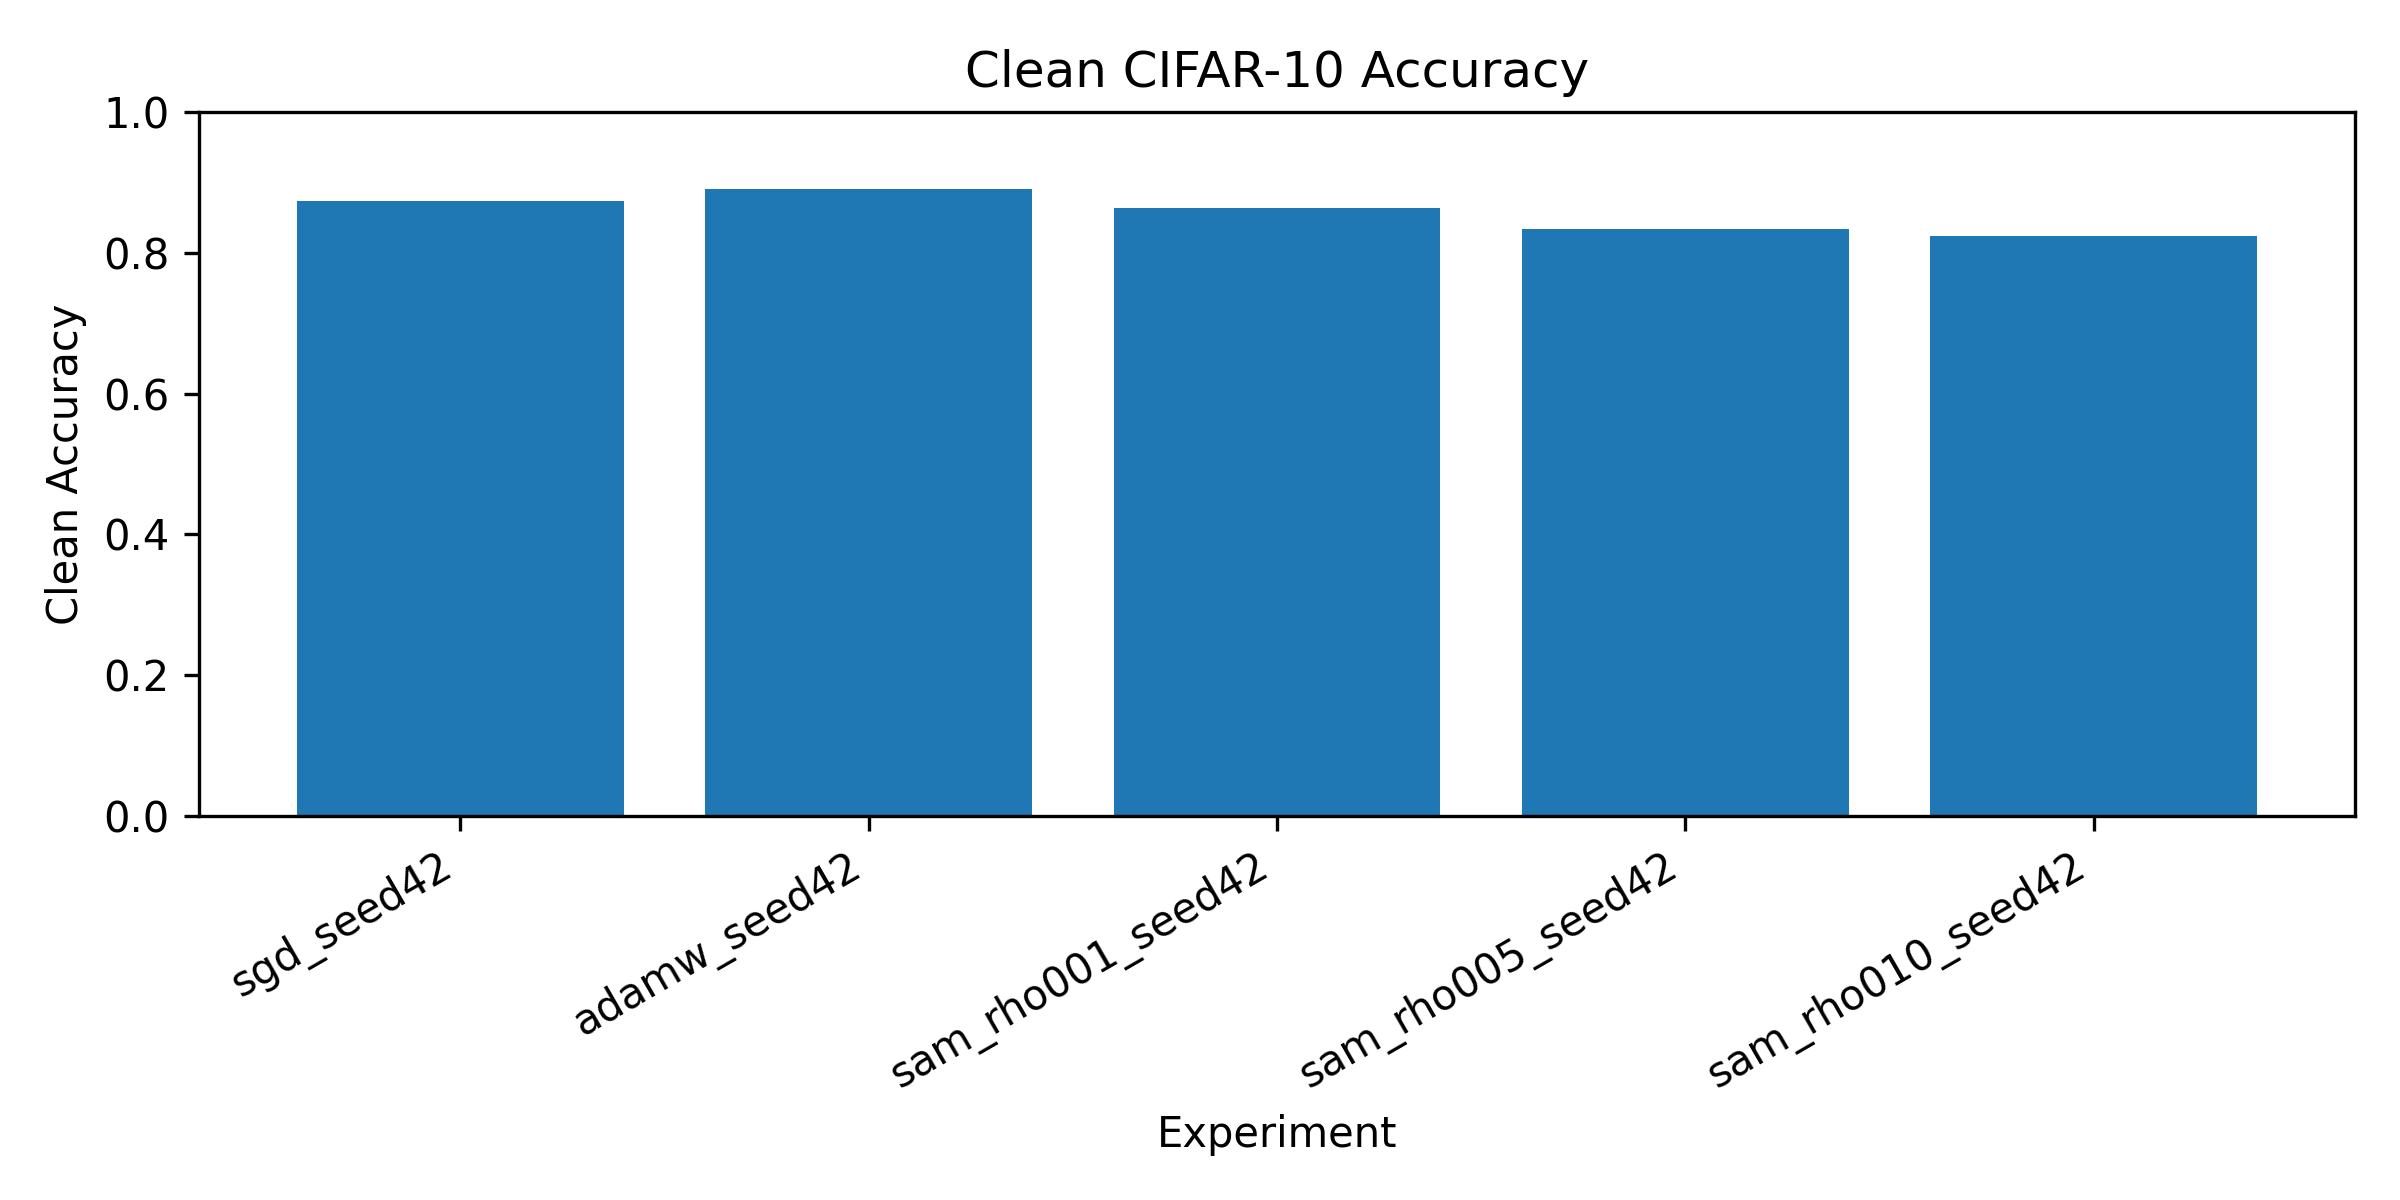


cifar10c_accuracy_comparison.png


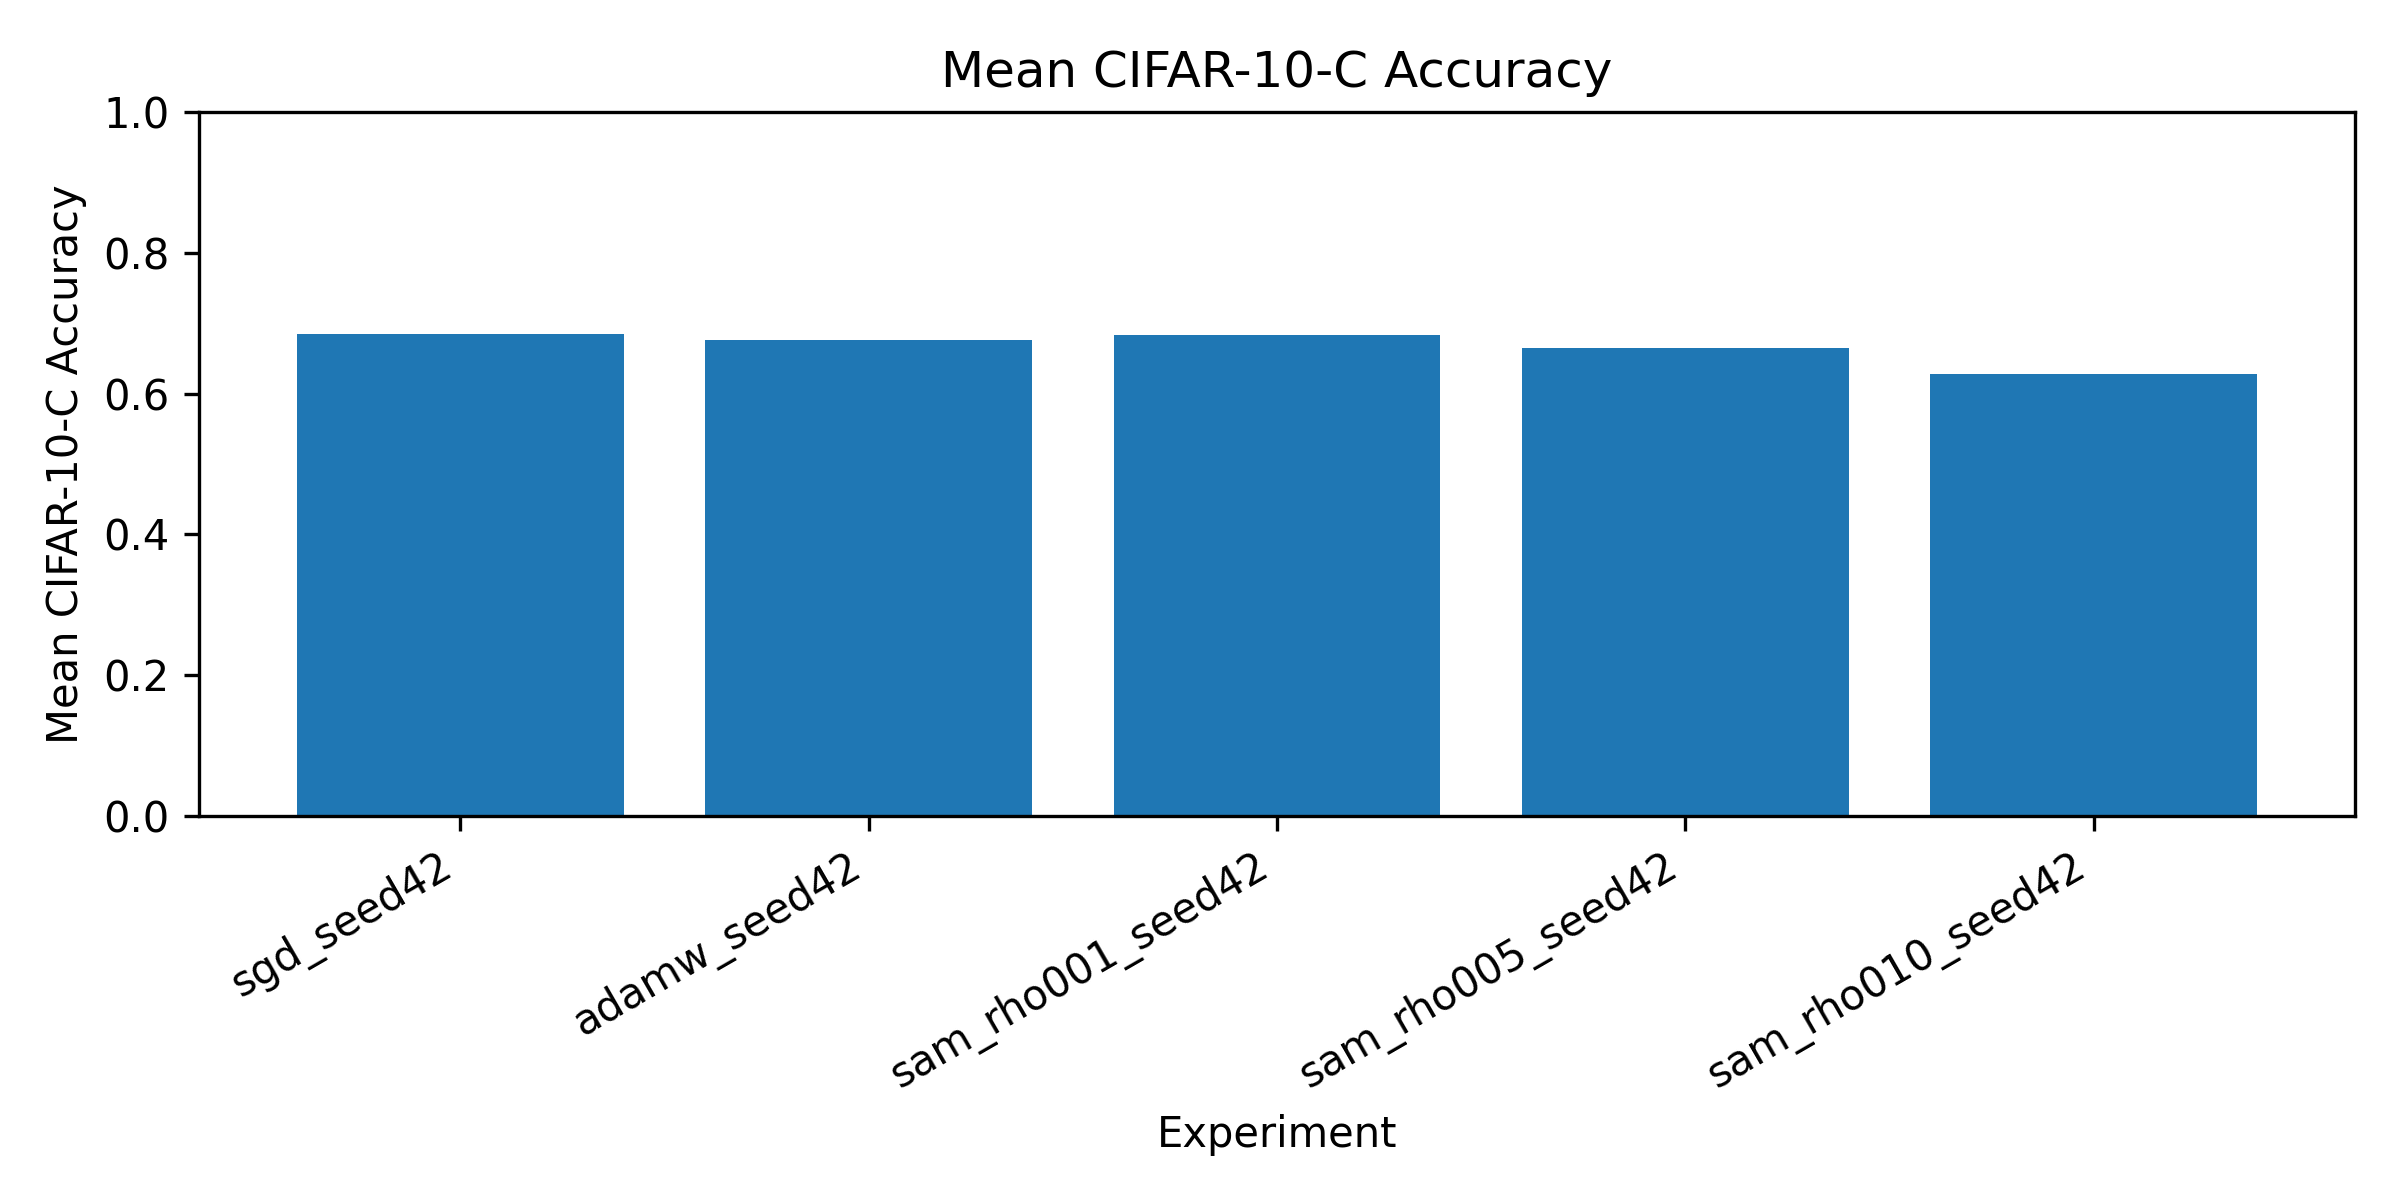


robustness_gap.png


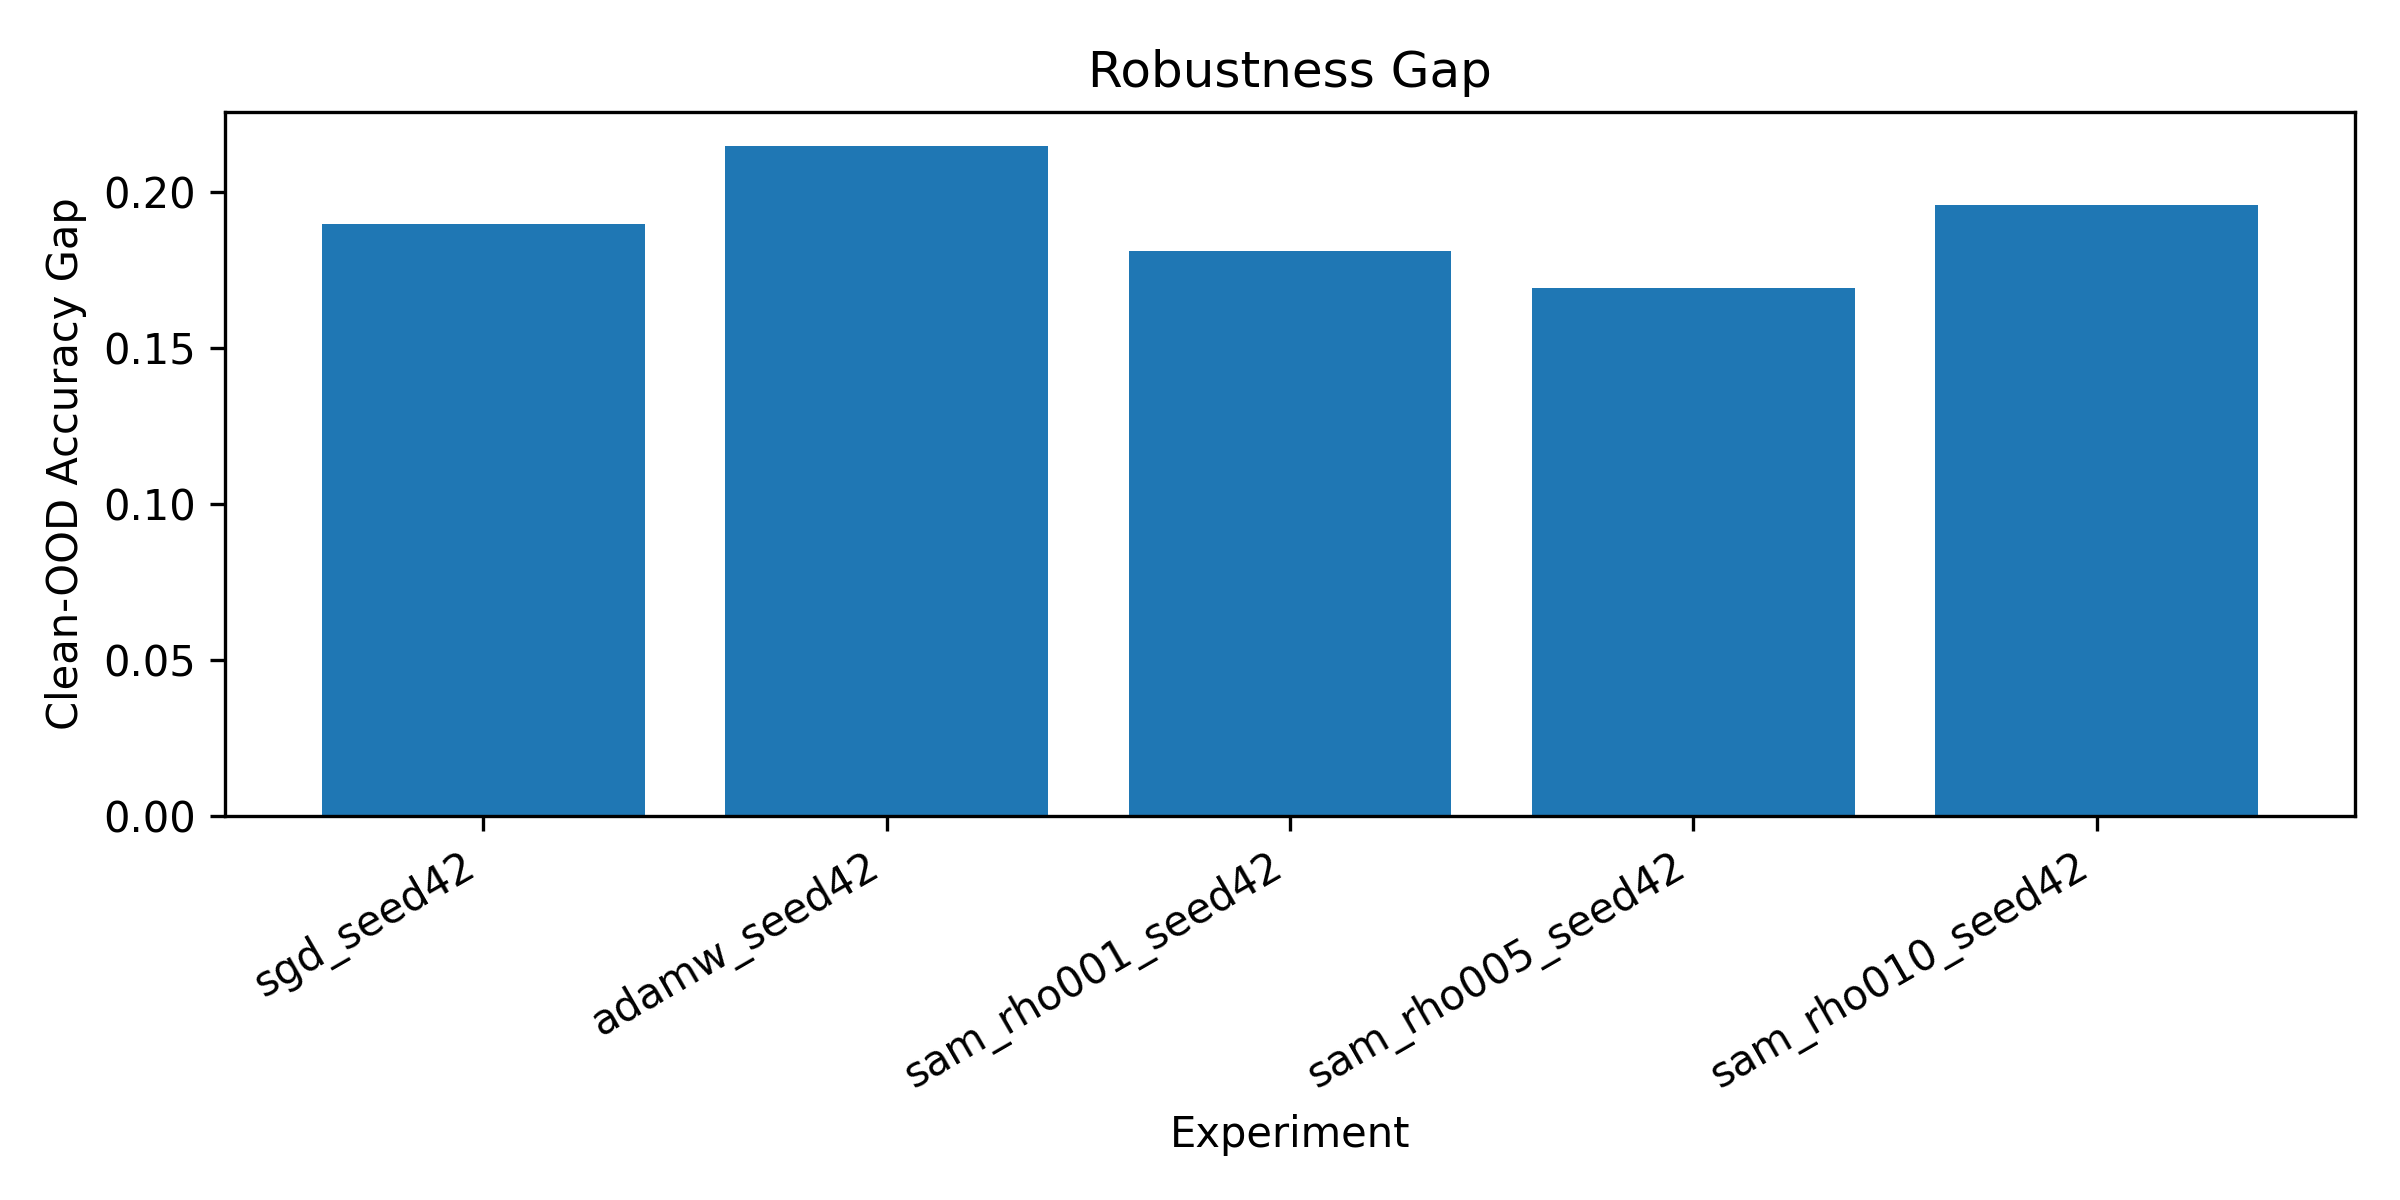


sharpness_comparison.png


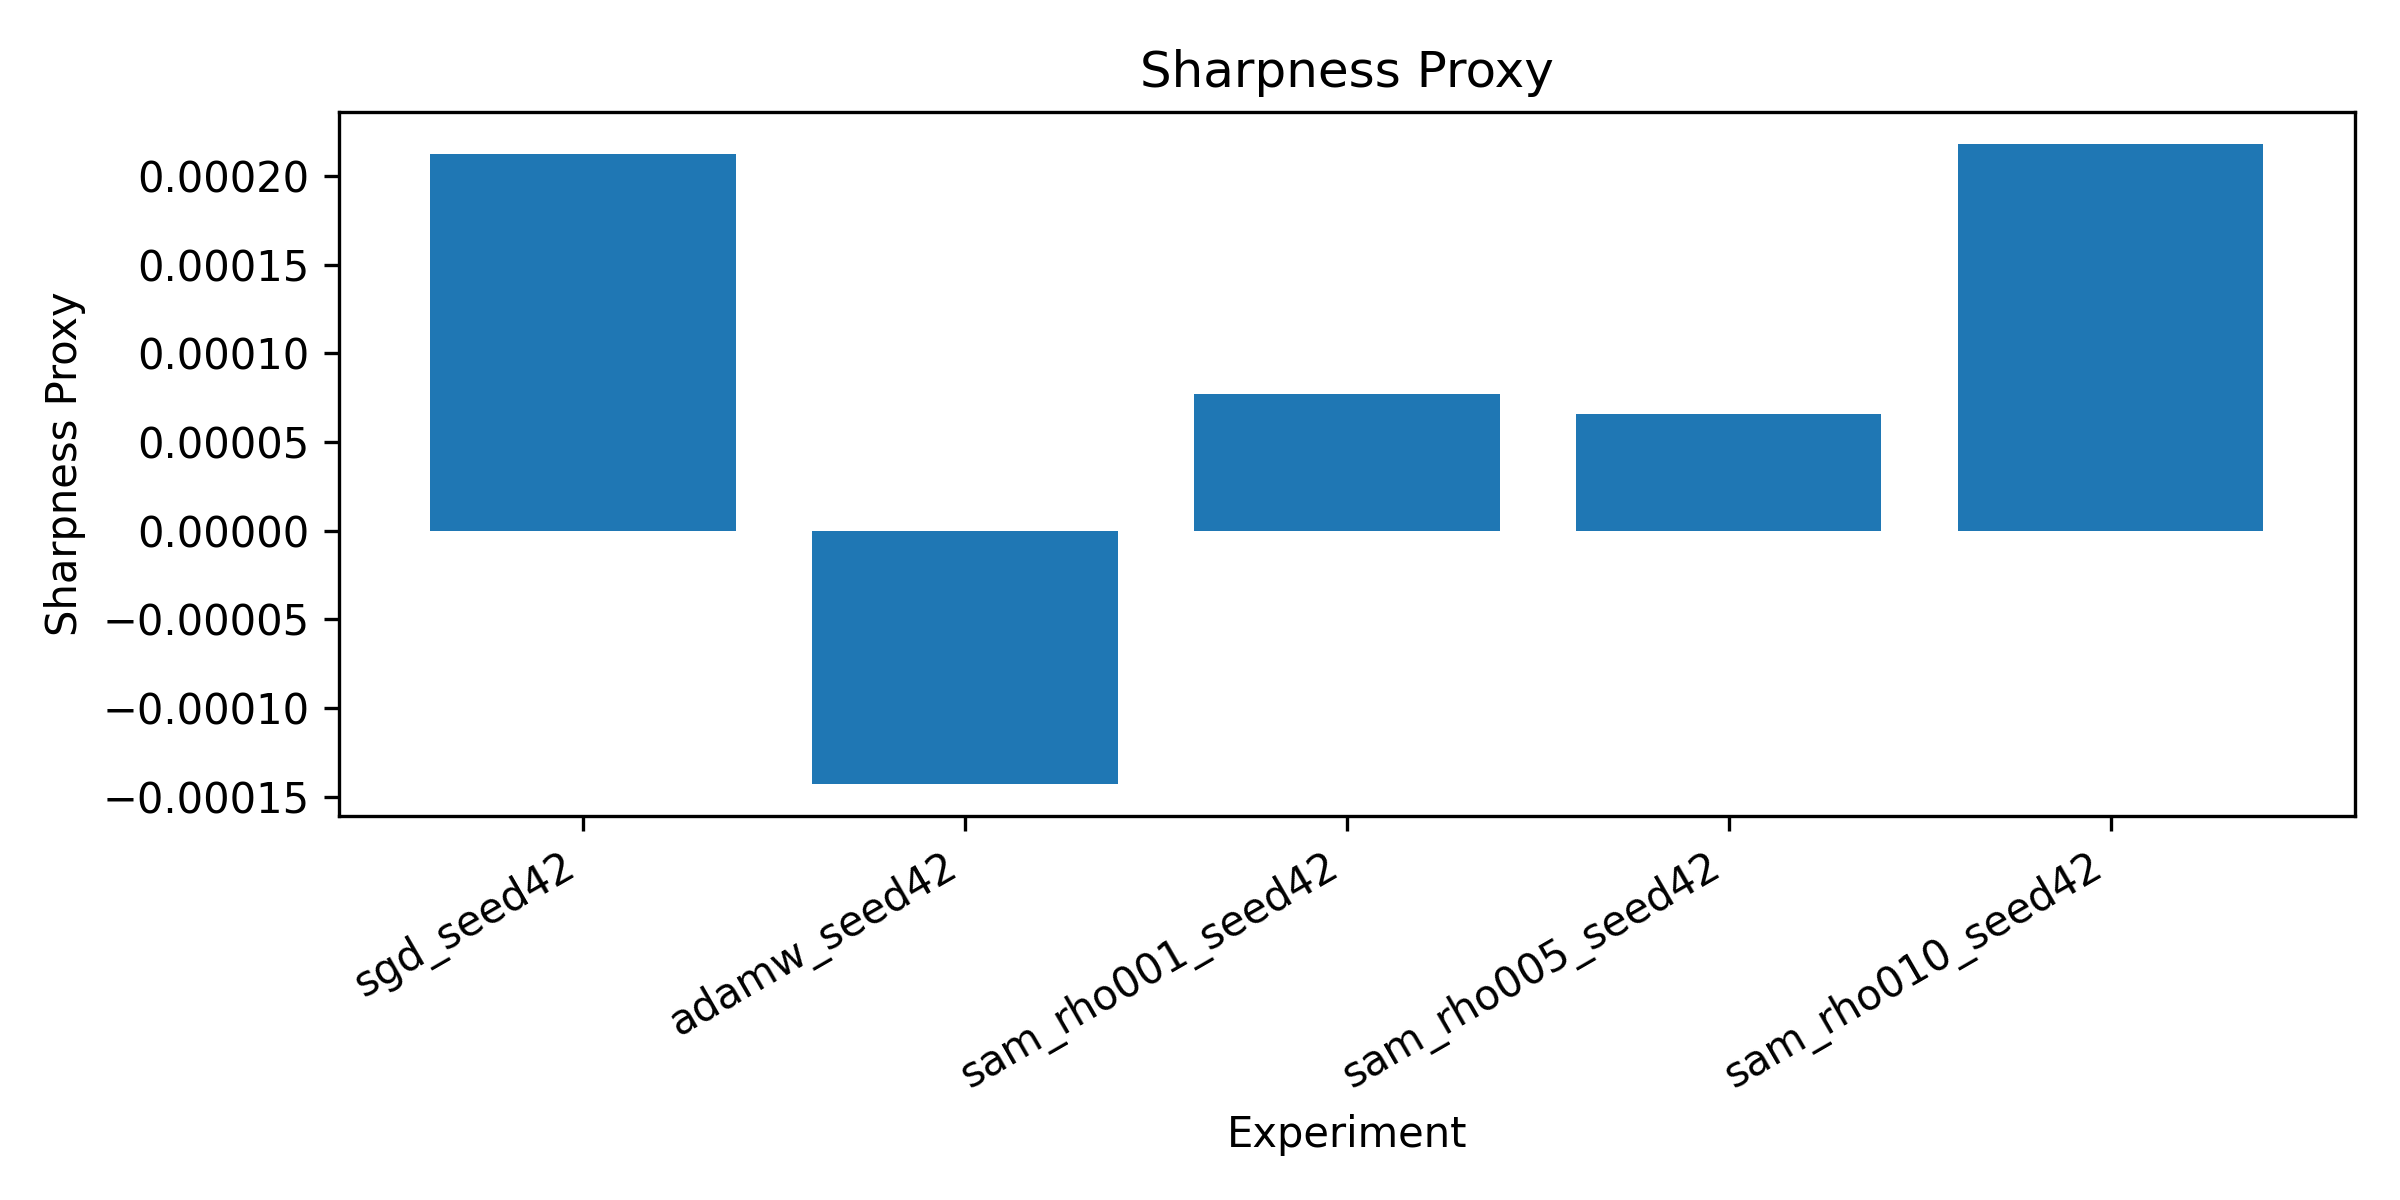


feature_stability_comparison.png


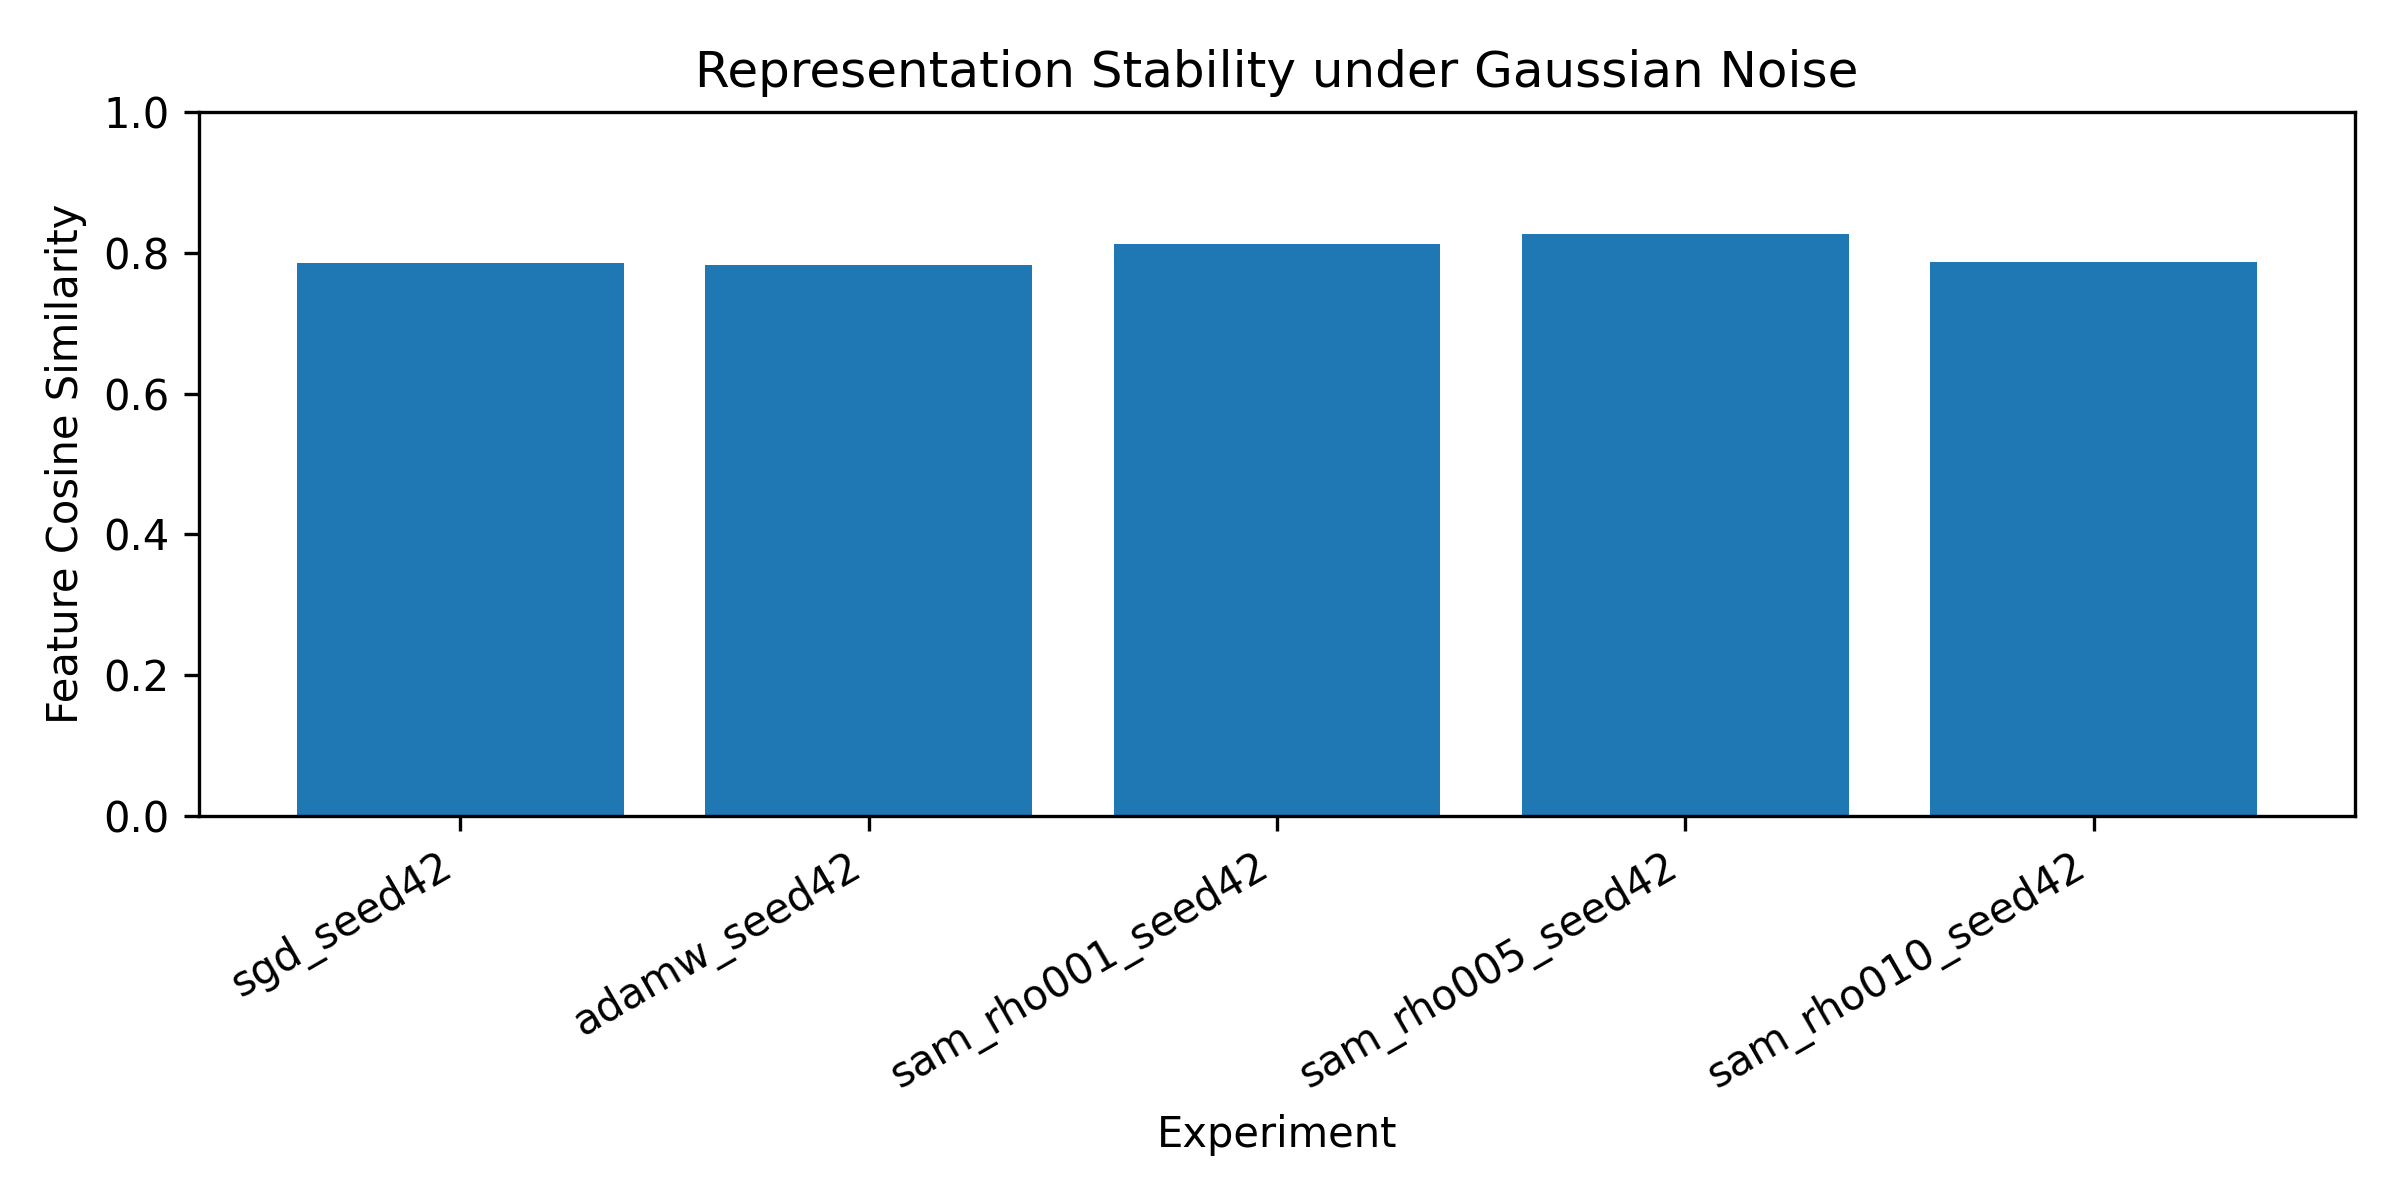


cifar10c_severity_accuracy.png


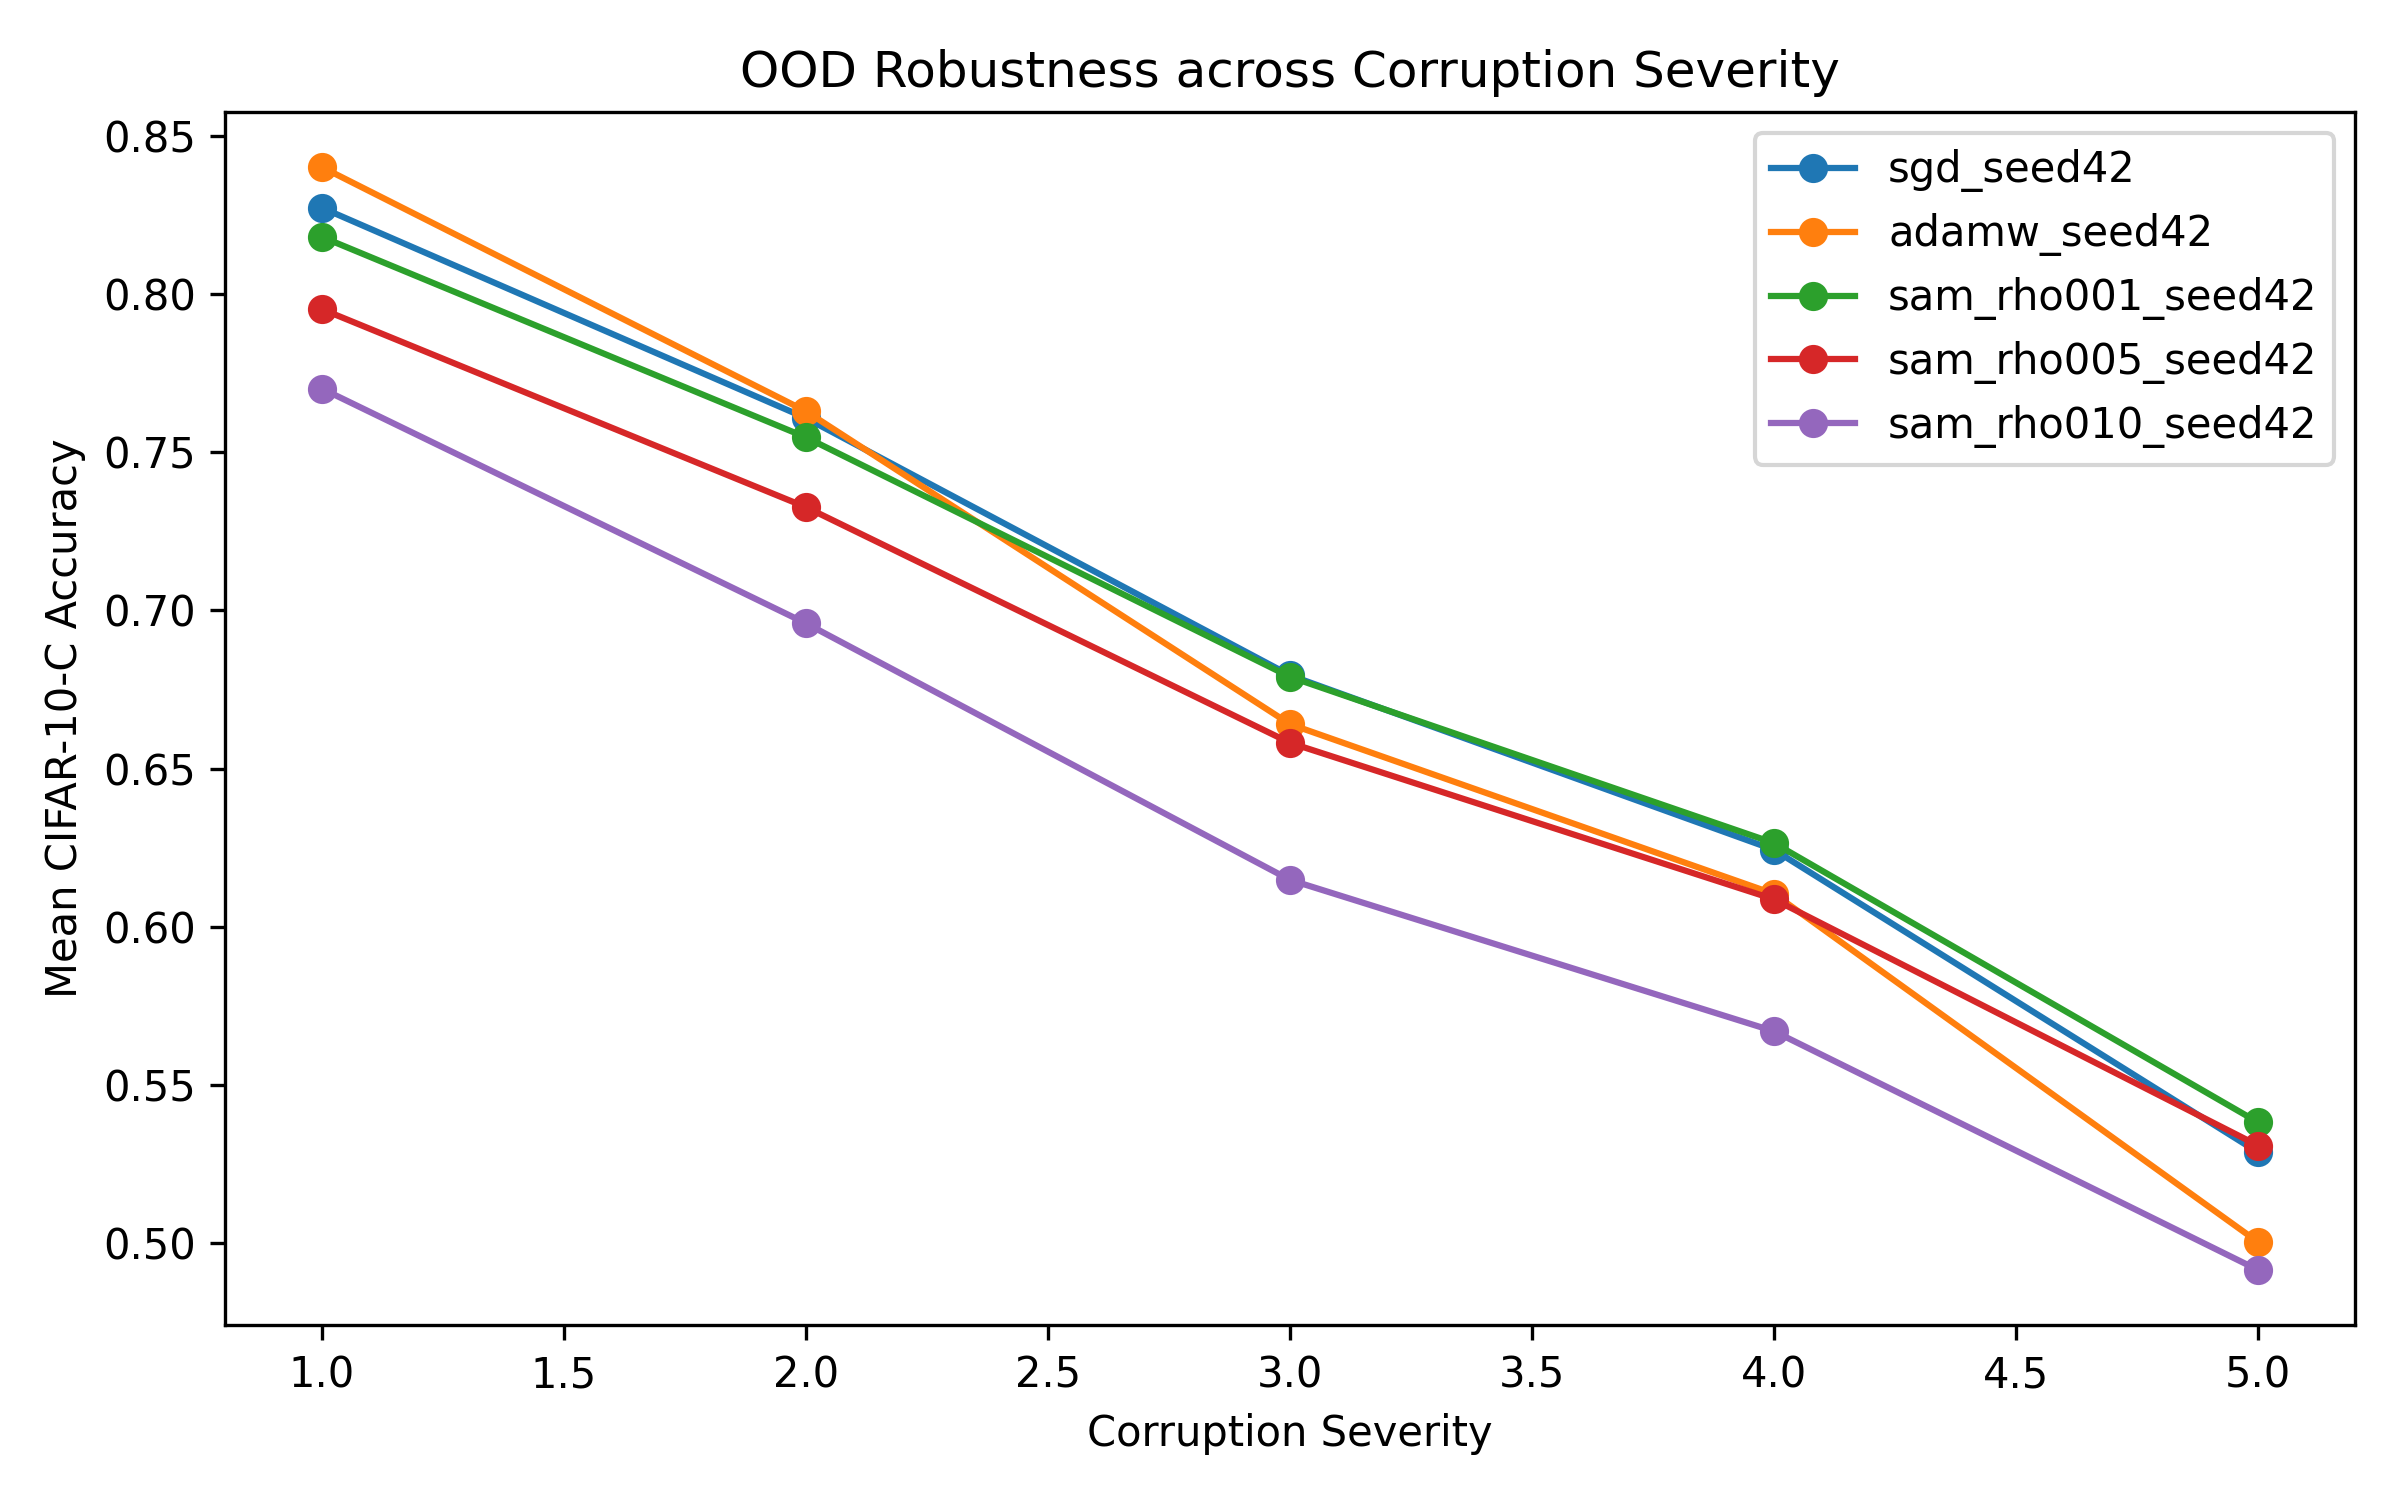


corruption_wise_accuracy.png


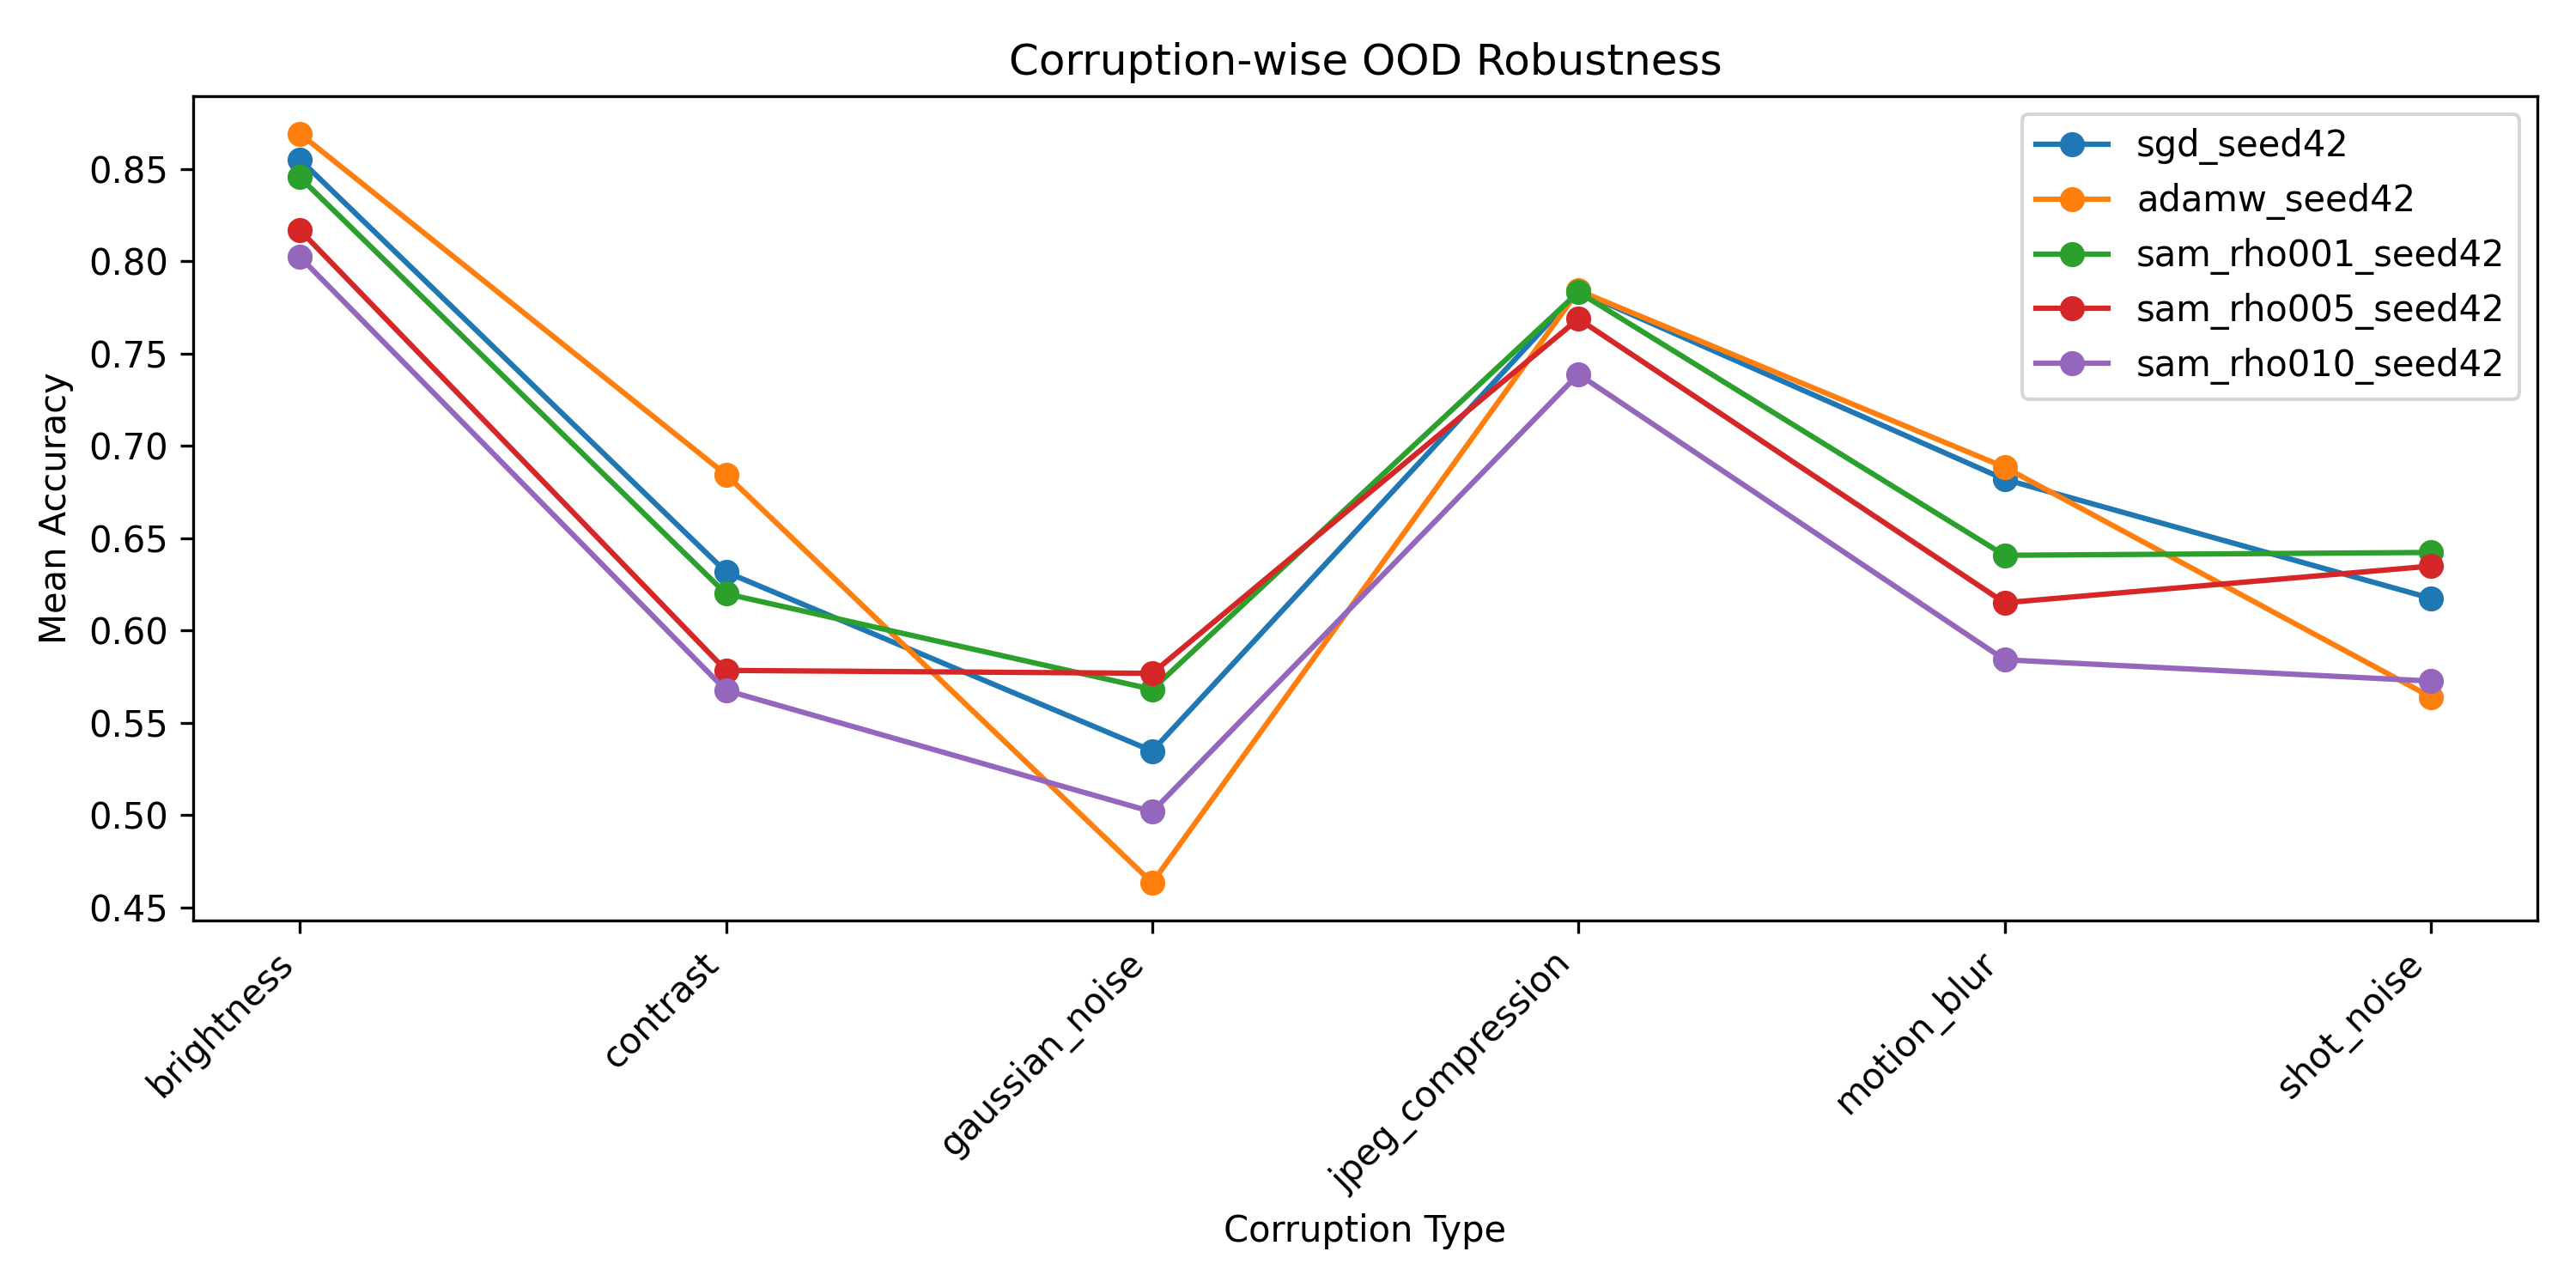


sharpness_vs_ood_accuracy.png


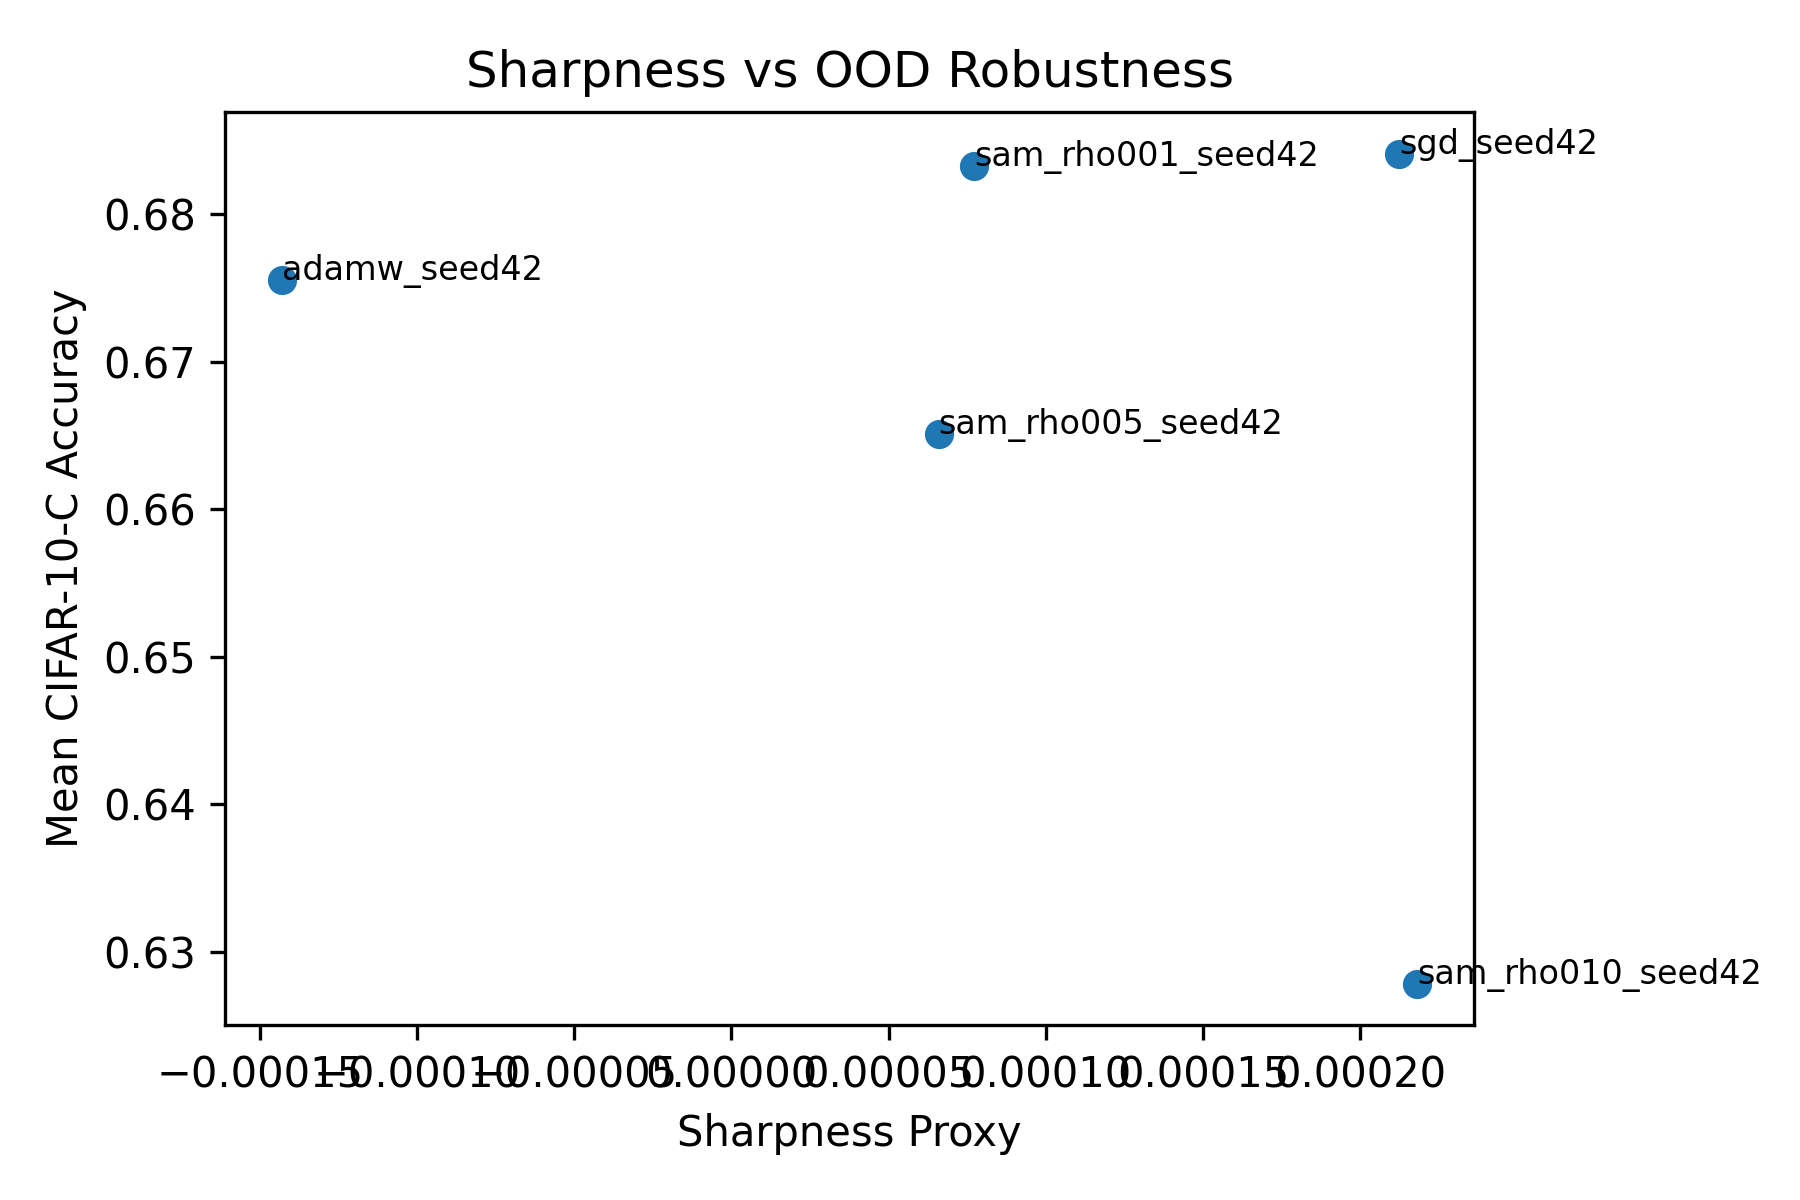


stability_vs_ood_accuracy.png


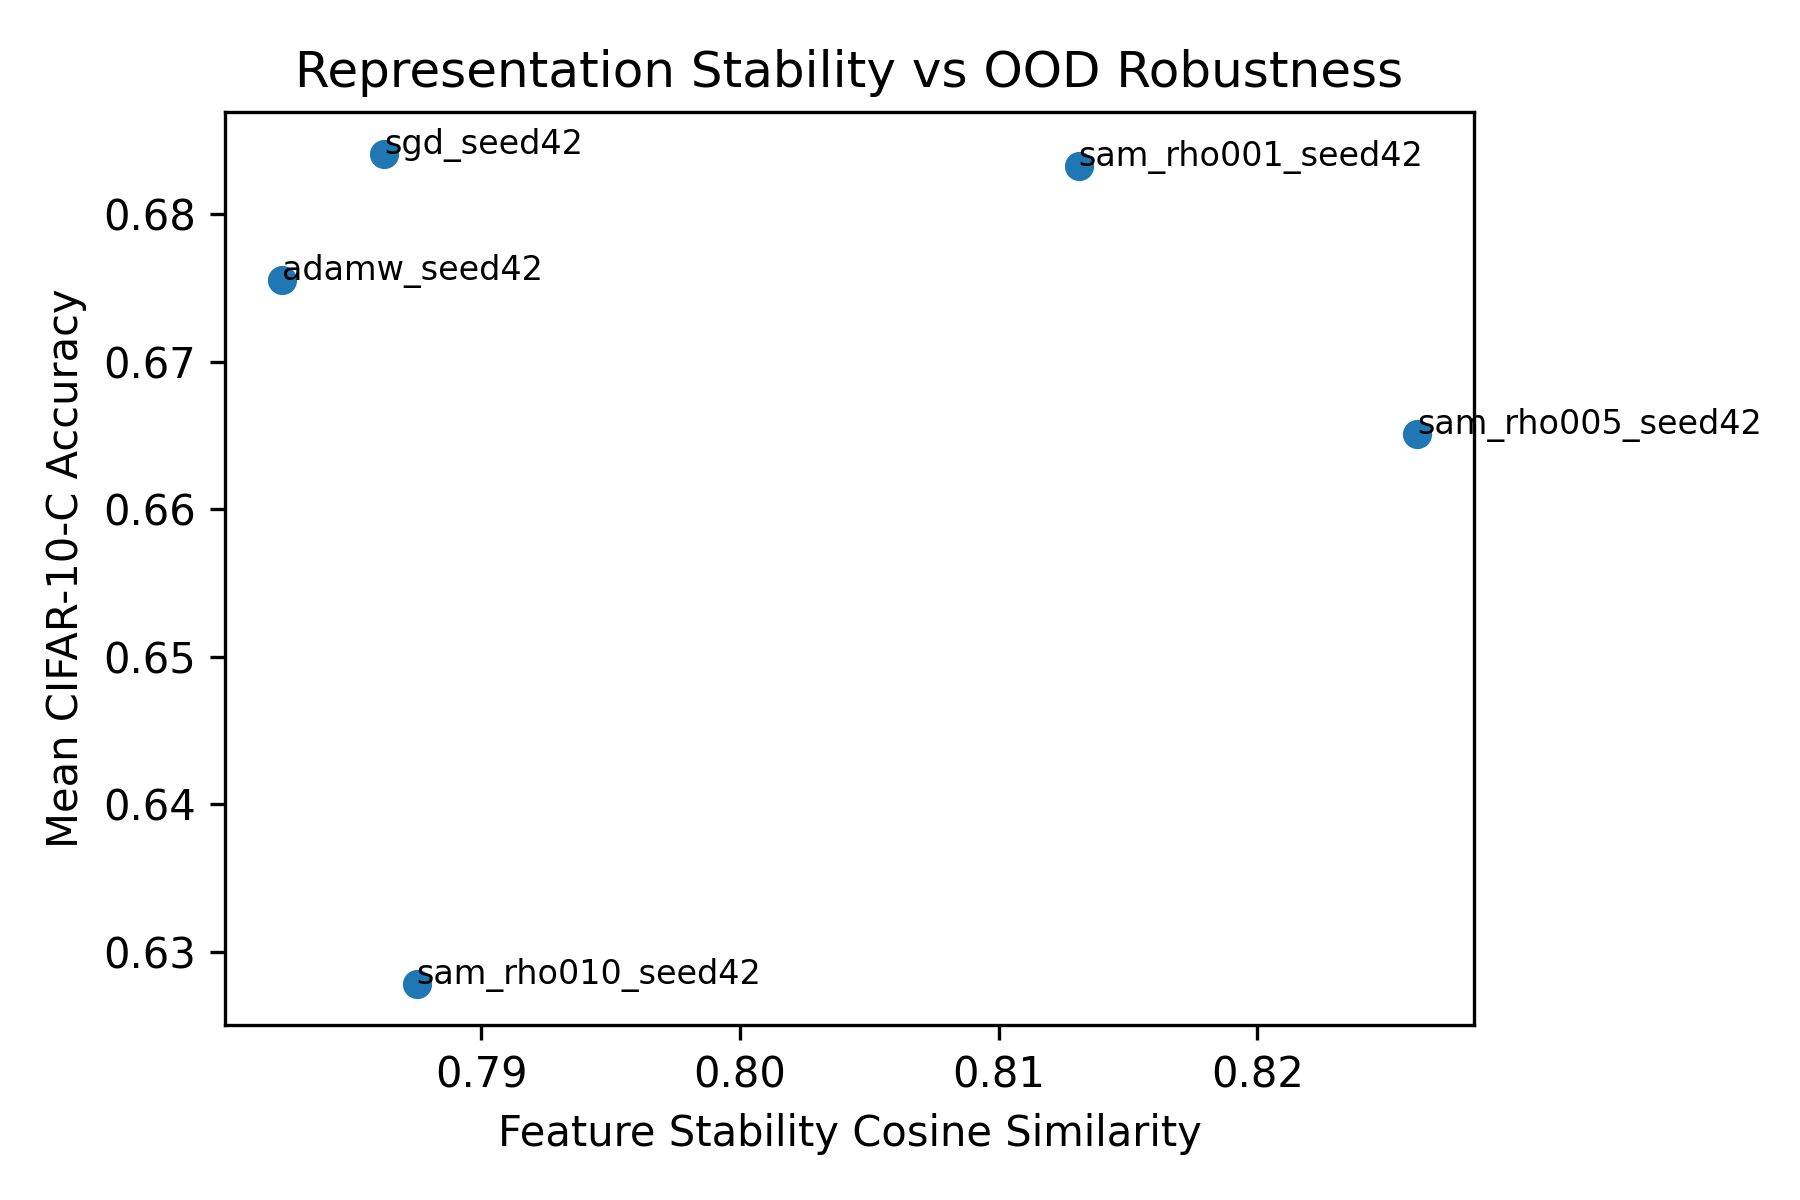


layerwise_representation_stability.png


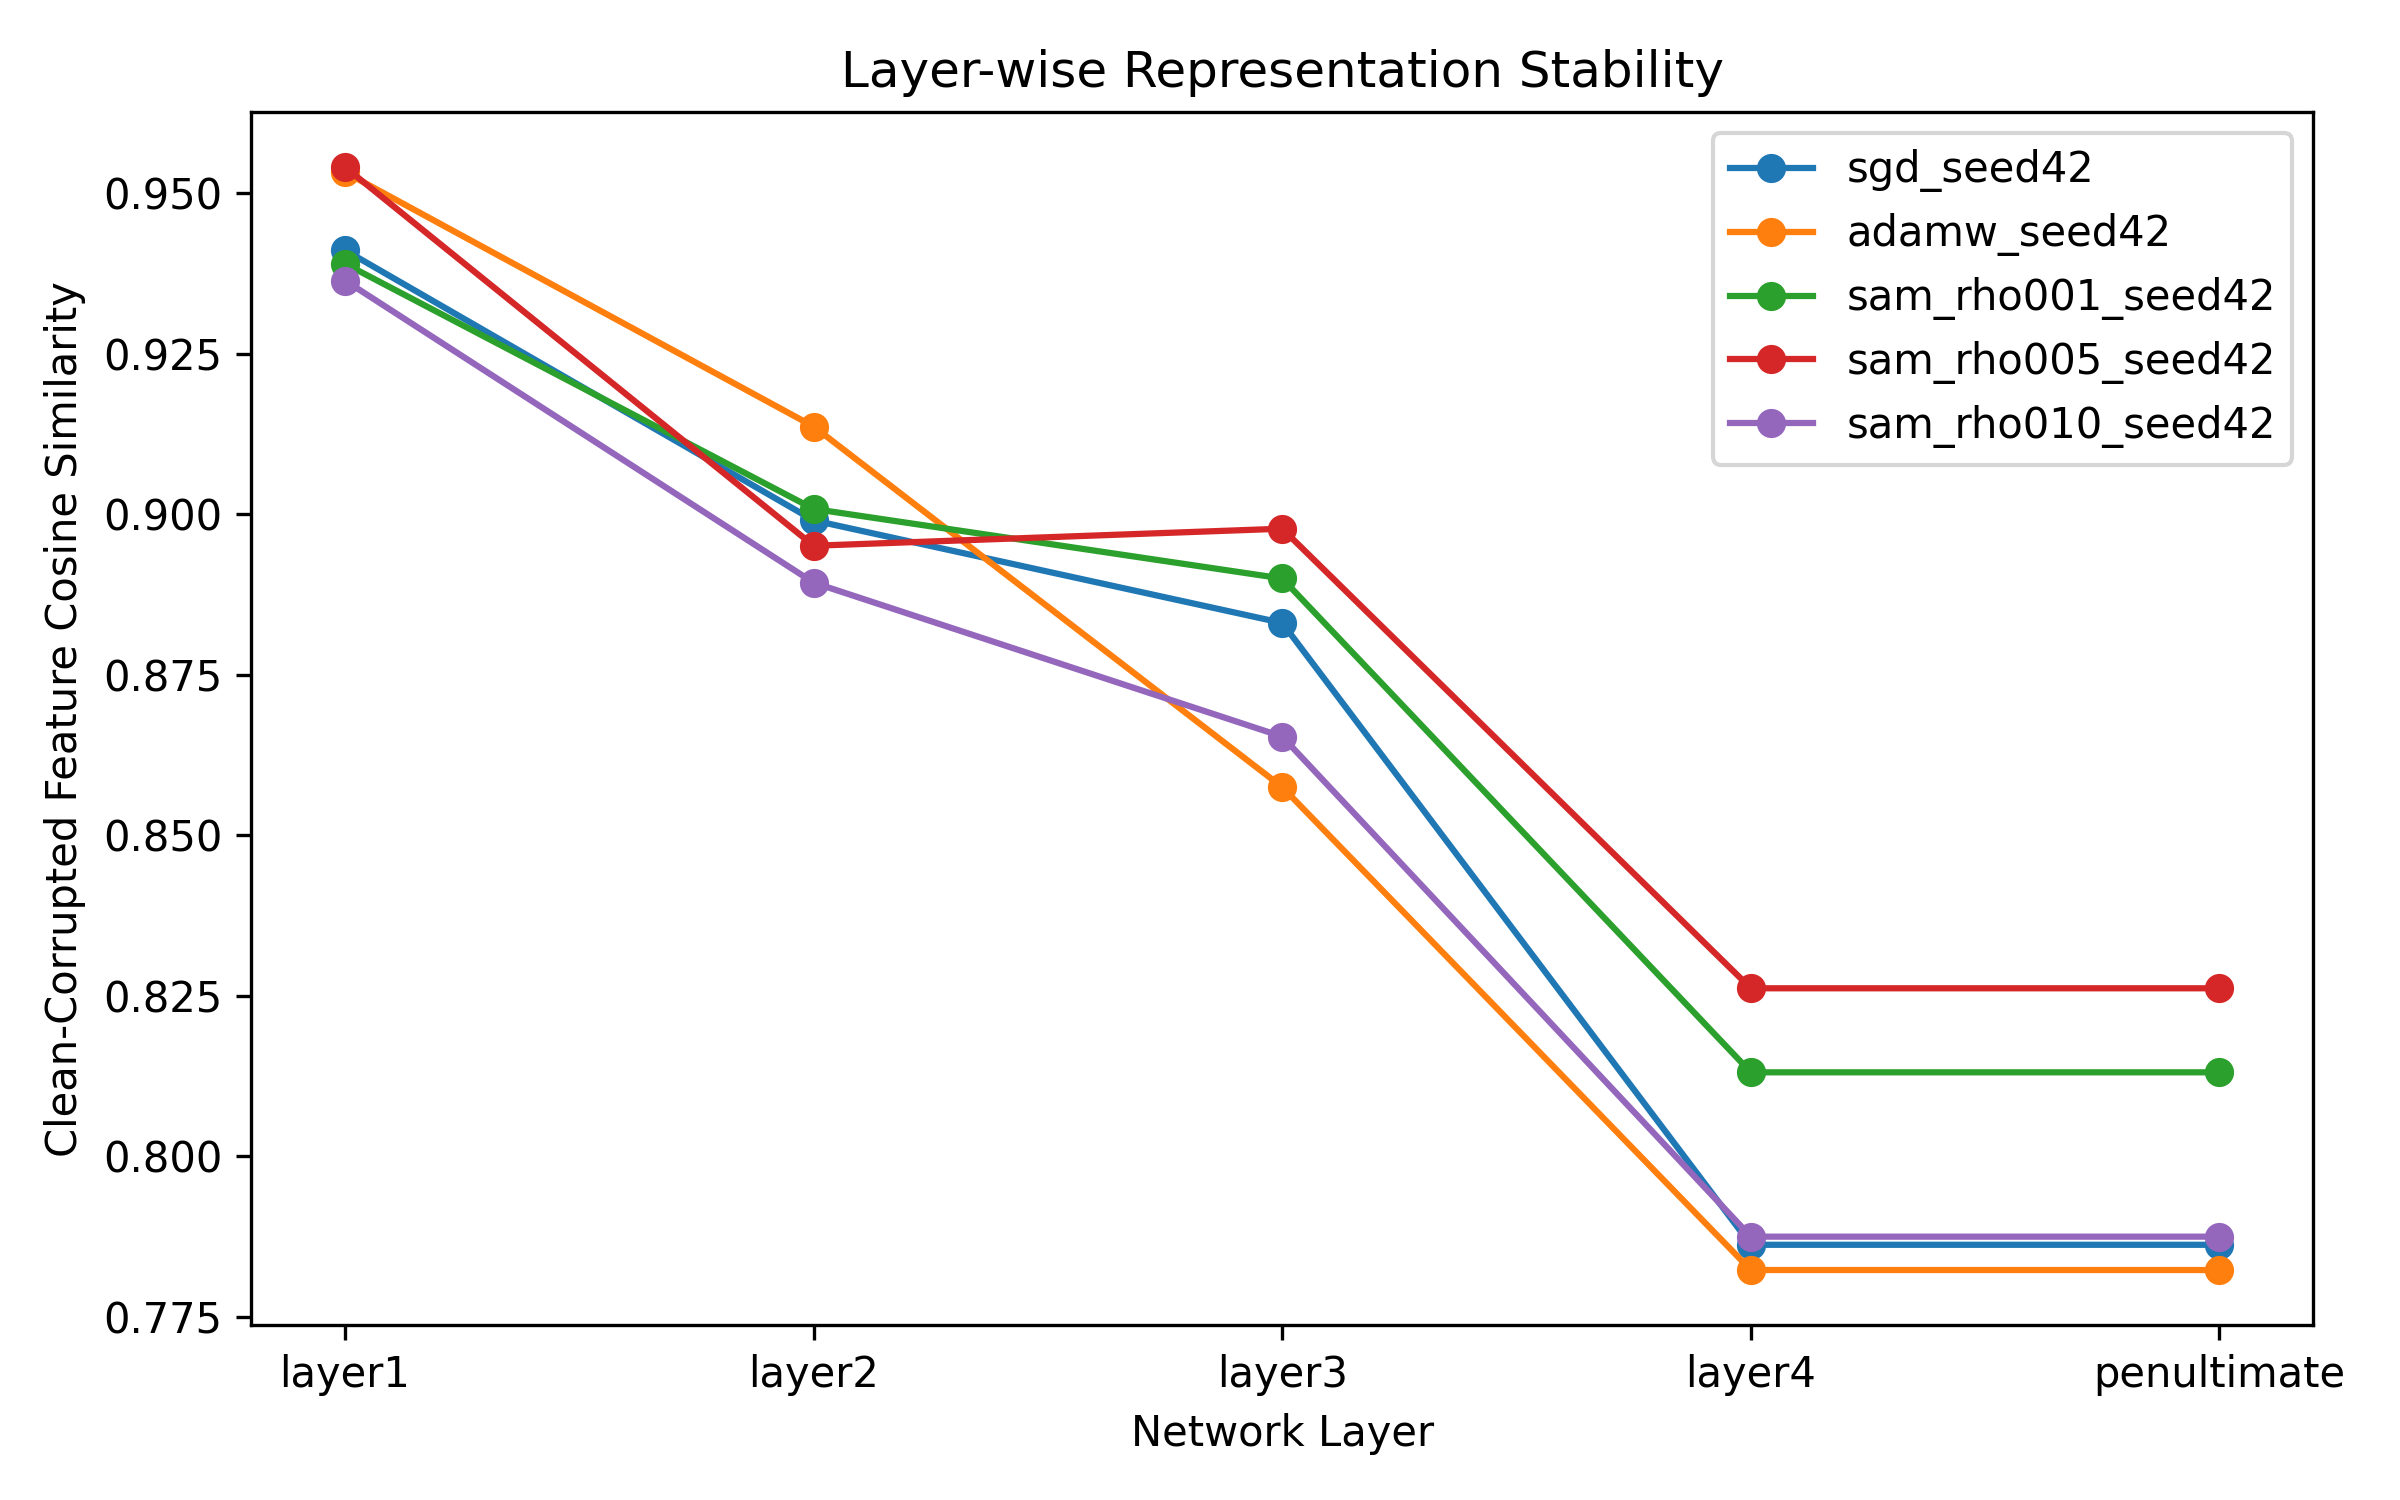


layerwise_cka.png


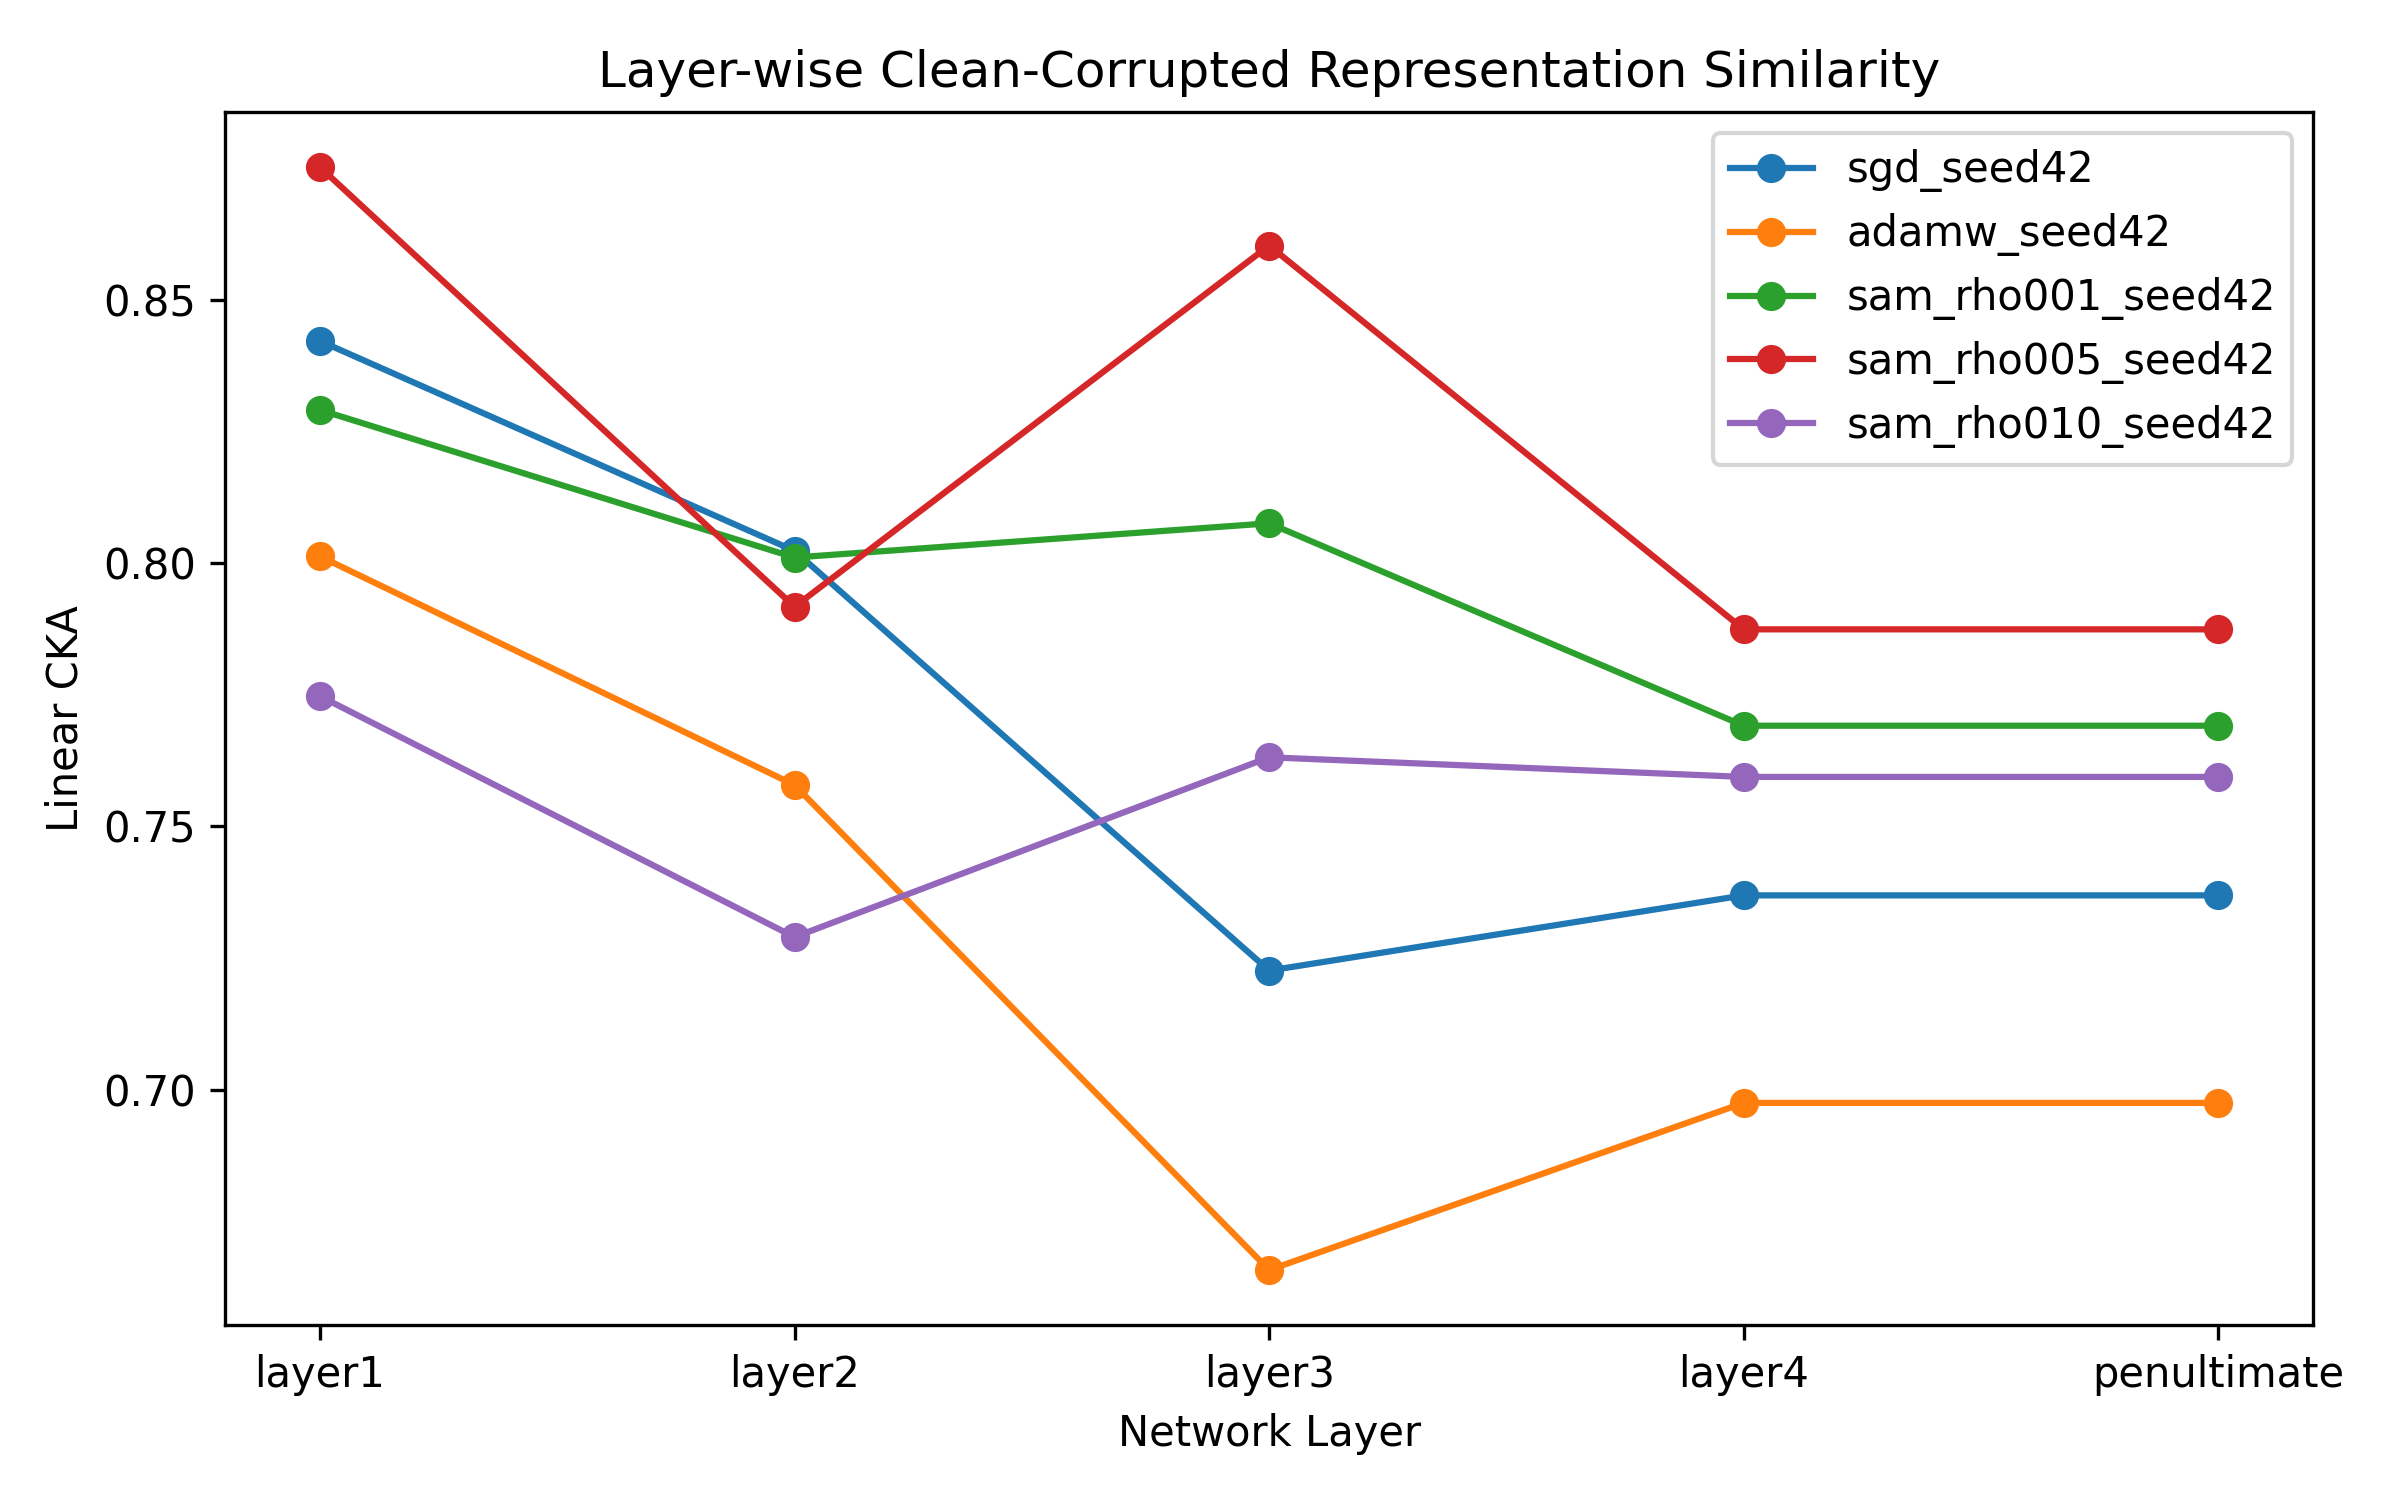

In [ ]:
from IPython.display import Image, display
import os

figure_files = [
    "clean_accuracy_comparison.png",
    "cifar10c_accuracy_comparison.png",
    "robustness_gap.png",
    "sharpness_comparison.png",
    "feature_stability_comparison.png",
    "cifar10c_severity_accuracy.png",
    "corruption_wise_accuracy.png",
    "sharpness_vs_ood_accuracy.png",
    "stability_vs_ood_accuracy.png",
    "layerwise_representation_stability.png",
    "layerwise_cka.png",
]

for fig in figure_files:
    path = os.path.join("figures", fig)
    if os.path.exists(path):
        print("\n" + fig)
        display(Image(filename=path))
    else:
        print("Missing:", fig)


## 9. Reproducibility and Submission Checklist

Before final submission, check the following items:

```text
[ ] The notebook was run from the correct Google Drive project folder.
[ ] All five checkpoints exist in checkpoints/.
[ ] CIFAR-10-C evaluation CSVs exist for SGD, AdamW, and all SAM rho values.
[ ] final_summary_results.csv matches the report's main result table.
[ ] run_metadata.csv records checkpoint path, checkpoint modified time, hash, config, seed, and run time.
[ ] plots.py has regenerated all figures used in the report.
[ ] The report discusses limitations honestly, especially the single-seed setting and the noisy sharpness proxy.
```

This checklist helps satisfy the assignment's emphasis on methodological soundness, fair comparison, informative figures, and clear research presentation.
